In [2]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview
from scipy import linalg

In [3]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [4]:
G_hi = 20.5

In [5]:
nthreads = 18

In [6]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [7]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [8]:
Delta = 200
delta_c = 1.686

In [9]:
hmf = ccl.halos.MassFuncTinker10()

In [10]:
NSIDE = 64

In [11]:
M_max = 15

## Define functions

In [12]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [13]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [14]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [15]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [16]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [17]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [18]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [19]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [20]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [21]:
bins = np.logspace(9, M_max, 79)

In [22]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [23]:
fduty_old = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_192581/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_192581/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


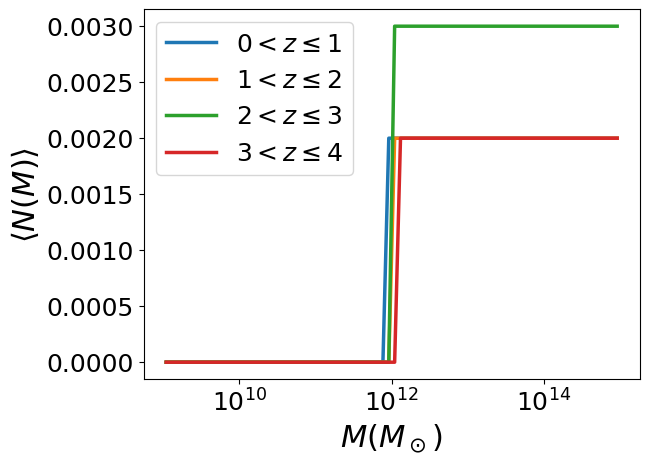

In [24]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [25]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [26]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [27]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

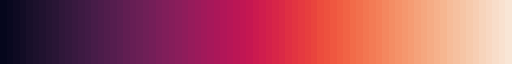

In [28]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [29]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [30]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

# Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [31]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _, pixel_indices_datahi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

0.6894778799187598
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              224099 vs 324336
0.6998052038245415
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464321 vs 648196
0.7010382664423291
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6: 0.22              28576 vs 36458


In [32]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [33]:
LMC_radius = 9*u.deg

In [34]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [35]:
SMC_radius = 5*u.deg

In [36]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    cp = np.percentile(selfunc_hi_bins[j][MC_mask], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)
    
n_q

0.3815553400077859
0.3990266387789277
0.42567567827451197
0.43715916212910605


[1.1562053955390066e-05,
 8.122737301033735e-06,
 3.0936220453800634e-06,
 2.72364137384074e-07]

In [37]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [38]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [39]:
# Create the bins array
rmin = 30 #-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80 #+delta_max*offset # 200
nbins = 10 #int((rmax-rmin)/offset)
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80.]),
 array([32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 77.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [40]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
a_zbin = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Planck18.Om0, h = Planck18.h, error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

0.6894778799187598
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              224099 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.6998052038245415
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464321 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.7010382664423291
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              214535 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6: 0.22              28576 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_192581/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_192581/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [41]:
rpmask = (quaia.recenter(rbins_chi2) >= 30) & (quaia.recenter(rbins_chi2) <= 80)

## Compute the maximum number of jackknife regions

In [42]:
N_j = 20

In [43]:
for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    cp = np.percentile(selfunc_hi_bins[j][MC_mask], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    
    # calculating N_jk first
    s_min = Planck18.comoving_transverse_distance(1/a_zbin[j]-1)*2*np.pi*Planck18.h/u.h
    N_jk_max = np.floor(s_min/(5*rmax*s_min.unit))
    theta_min = np.ceil(360/N_jk_max)
    
    # calculating theta first
    # s_min = Planck18.comoving_distance(1/a_zbin[j]-1)*Planck18.h/u.h
    # theta_min = np.ceil(np.rad2deg(rmax*s_min.unit/s_min*u.rad))
    # N_jk_max = np.floor(360*u.deg/theta_min)

    print('N_j_max:', N_jk_max)
    print('N_q:', int(N_q[j]/N_j))
    print('theta_min:', theta_min)
    print()
    
print('hartlap:', (N_j-nbins-2)/(N_j-1))
print('dodelson:', 1+nbins/N_j)

N_j_max: 28.0
N_q: 11204
theta_min: 13.0

N_j_max: 47.0
N_q: 23216
theta_min: 8.0

N_j_max: 61.0
N_q: 10726
theta_min: 6.0

N_j_max: 71.0
N_q: 1428
theta_min: 6.0

hartlap: 0.42105263157894735
dodelson: 1.5


In [44]:
21578/N_j

1078.9

# Perform nested sampling with dynesty

In [45]:
# Define the dimensionality of our problem.
ndim = 2

## Pick cosmology

In [46]:
cosmo = 'Planck'

In [47]:
N = 30 # 15 #45 #85

In [48]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
ix_grid = np.ix_(rpmask, rpmask)
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

# check if cov is hermitian and positive definite
if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
    C_factor = linalg.cho_factor(C[ix_grid])
    log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
    solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
else:
    print('using LU decomposition')
    C_factor = linalg.lu_factor(C[ix_grid])
    log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
    solve = lambda rhs: linalg.lu_solve(C_factor, rhs)

def loglike(x, a, cf_matter, log_det_C, cf, n_q, nbins, cosmo = cosmo_planck18, error = 0.05, hartlap = hartlap, solve = solve):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
    
    # Cinv = np.linalg.inv(C)
    lnorm = -0.5 * (np.log(2 * np.pi) * nbins + log_det_C)
                    # np.log(np.linalg.det(C)))
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    penalty = np.abs(n_q_theory-n_q)/n_q
    if penalty > error:
        penalty = np.inf
    
    # return -0.5 * np.dot(delta, np.dot(Cinv, delta)) + lnorm - penalty
    # return -0.5 * delta.T @ (hartlap*np.linalg.solve(C, delta)) + lnorm - penalty
    # return -0.5 * delta.T @ linalg.cho_solve(C_factor, delta) + lnorm - penalty
    return -0.5 * delta.T @ (hartlap*solve(delta)) + lnorm - penalty

0.6206896551724138


In [49]:
# check if cov is hermitian
linalg.ishermitian(C)

True

In [50]:
# check if cov is positive definite
# Check all eigen value
res = np.all(np.linalg.eigvals(C) > 0)

# Display result
print("Is matrix positive definite:\n",res)

Is matrix positive definite:
 True


In [51]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 0 to 1
    x[0] =  6* u[0] - 6 # scale and shift to [-6., 0.)

    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)

    return x

In [52]:
# initialize our nested sampler
# sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], log_det_C, cf_chi2[j][rpmask], n_q[j], nbins])

In [53]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = 0.005)
results = sampler.results

3379it [00:12, 276.87it/s, +500 | bound: 17 | nc: 1 | ncall: 37991 | eff(%): 10.346 | loglstar:   -inf < 17.826 <    inf | logz: 11.545 +/-    nan | dlogz:  0.000 >  0.005]


In [54]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 500
niter: 3379
ncall: 8991
eff(%): 10.346
logz: 11.545 +/-  0.110


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/2088523137.py:3: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)


Text(0.5, 0.9, '$3.0<z \\leq4.6$')

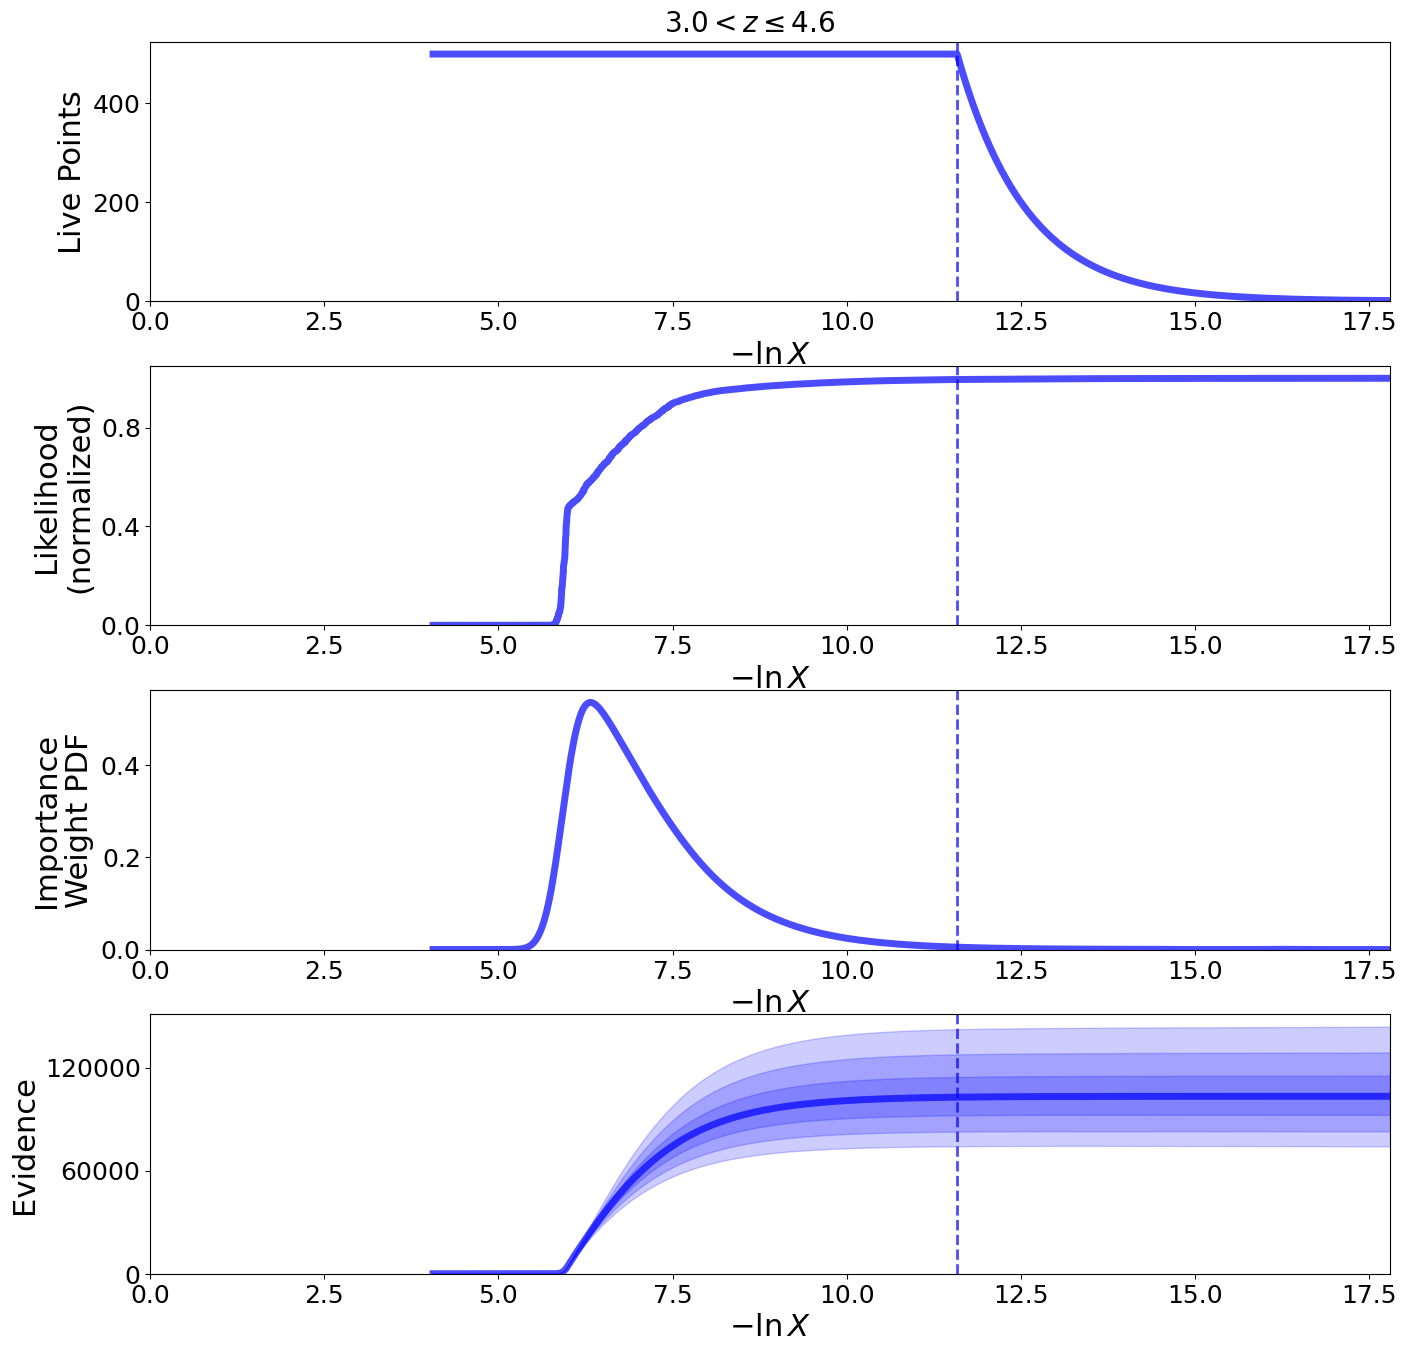

In [55]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/3722439029.py:6: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)


Text(0.5, 1, '$3.0<z \\leq4.6$')

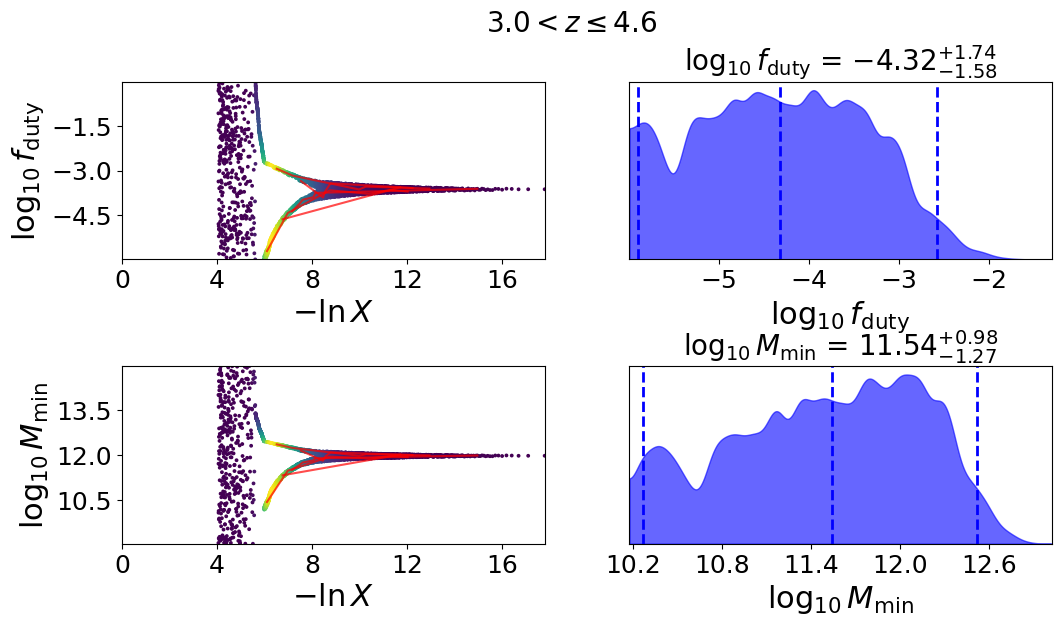

In [56]:
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/2504107271.py:7: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)


Text(0.6, 0.95, '$3.0<z \\leq4.6$')

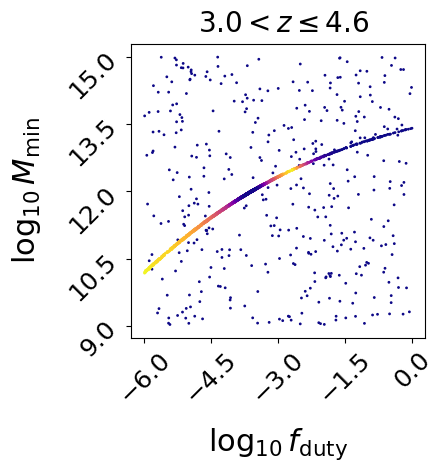

In [57]:
# initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/1206956469.py:8: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)


Text(0.375, 1, '$3.0<z \\leq4.6$')

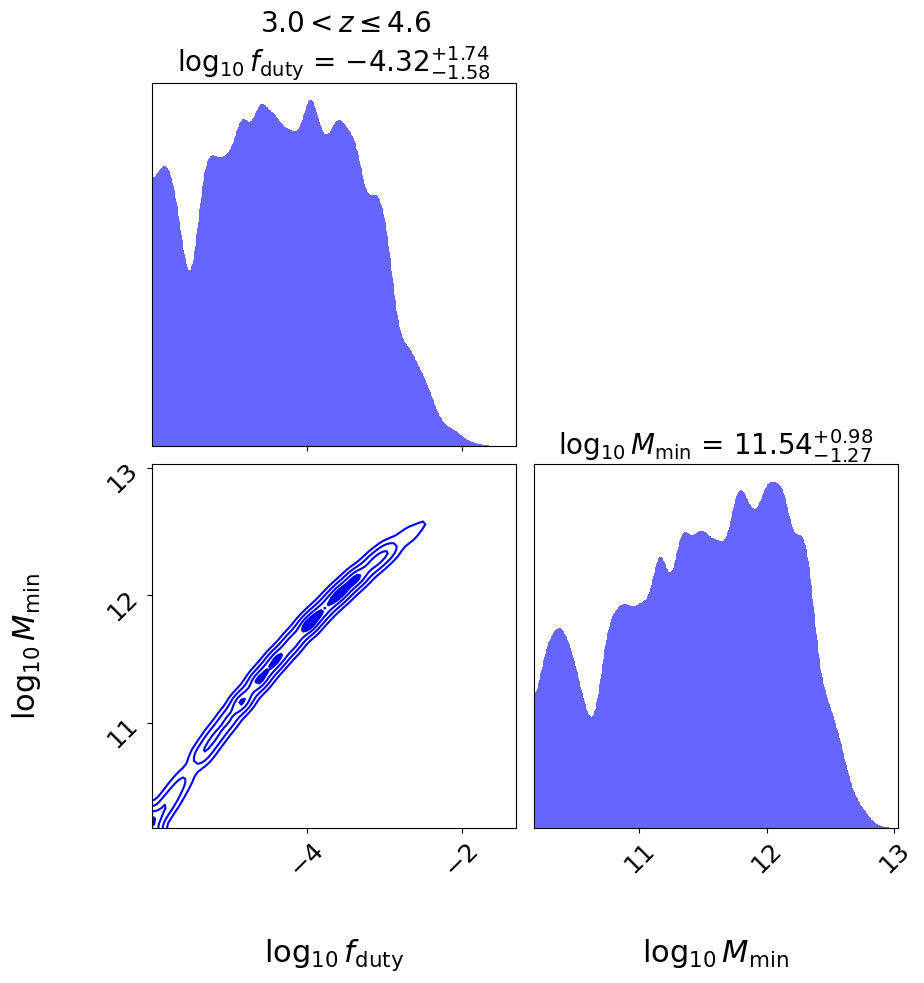

In [58]:
# # initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)

In [59]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-4.30993186 11.48584901] [[0.87272477 0.59544903]
 [0.59544903 0.41052401]]


In [60]:
# Compute weighted quantiles
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -4.32 + 1.74/-1.58
log10(M_min): 11.54 + 0.98/-1.27


## Across all $z$

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/3511267817.py:34: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
/tmp/ipykernel_192581/3511267817.py:41: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
/tmp/ipykernel_192581/3511267817.py:49: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)
/tmp/ipykernel_192581/3511267817.py:58: SyntaxW

Summary
nlive: 500
niter: 4448
ncall: 9797
eff(%): 16.606
logz: 28.922 +/-  0.124
0<z<=1
log10(f_duty): -2.78 + 0.14/-0.16
log10(M_min): 11.99 + 0.14/-0.16



4552it [00:14, 320.75it/s, +500 | bound: 19 | nc: 1 | ncall: 27742 | eff(%): 18.545 | loglstar:   -inf < 47.218 <    inf | logz: 39.038 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4552
ncall: 9742
eff(%): 18.545
logz: 39.038 +/-  0.125
1<z<=2
log10(f_duty): -2.94 + 0.11/-0.13
log10(M_min): 11.89 + 0.10/-0.12



4496it [00:15, 296.50it/s, +500 | bound: 21 | nc: 1 | ncall: 27835 | eff(%): 18.277 | loglstar:   -inf < 41.005 <    inf | logz: 32.995 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4496
ncall: 10835
eff(%): 18.277
logz: 32.995 +/-  0.124
2<z<=3
log10(f_duty): -2.70 + 0.16/-0.17
log10(M_min): 12.18 + 0.11/-0.12



3372it [00:11, 299.32it/s, +500 | bound: 16 | nc: 1 | ncall: 34176 | eff(%): 11.498 | loglstar:   -inf < 17.826 <    inf | logz: 11.652 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 3372
ncall: 8176
eff(%): 11.498
logz: 11.652 +/-  0.109
3<z<=4
log10(f_duty): -4.30 + 0.93/-1.12
log10(M_min): 11.56 + 0.57/-0.86



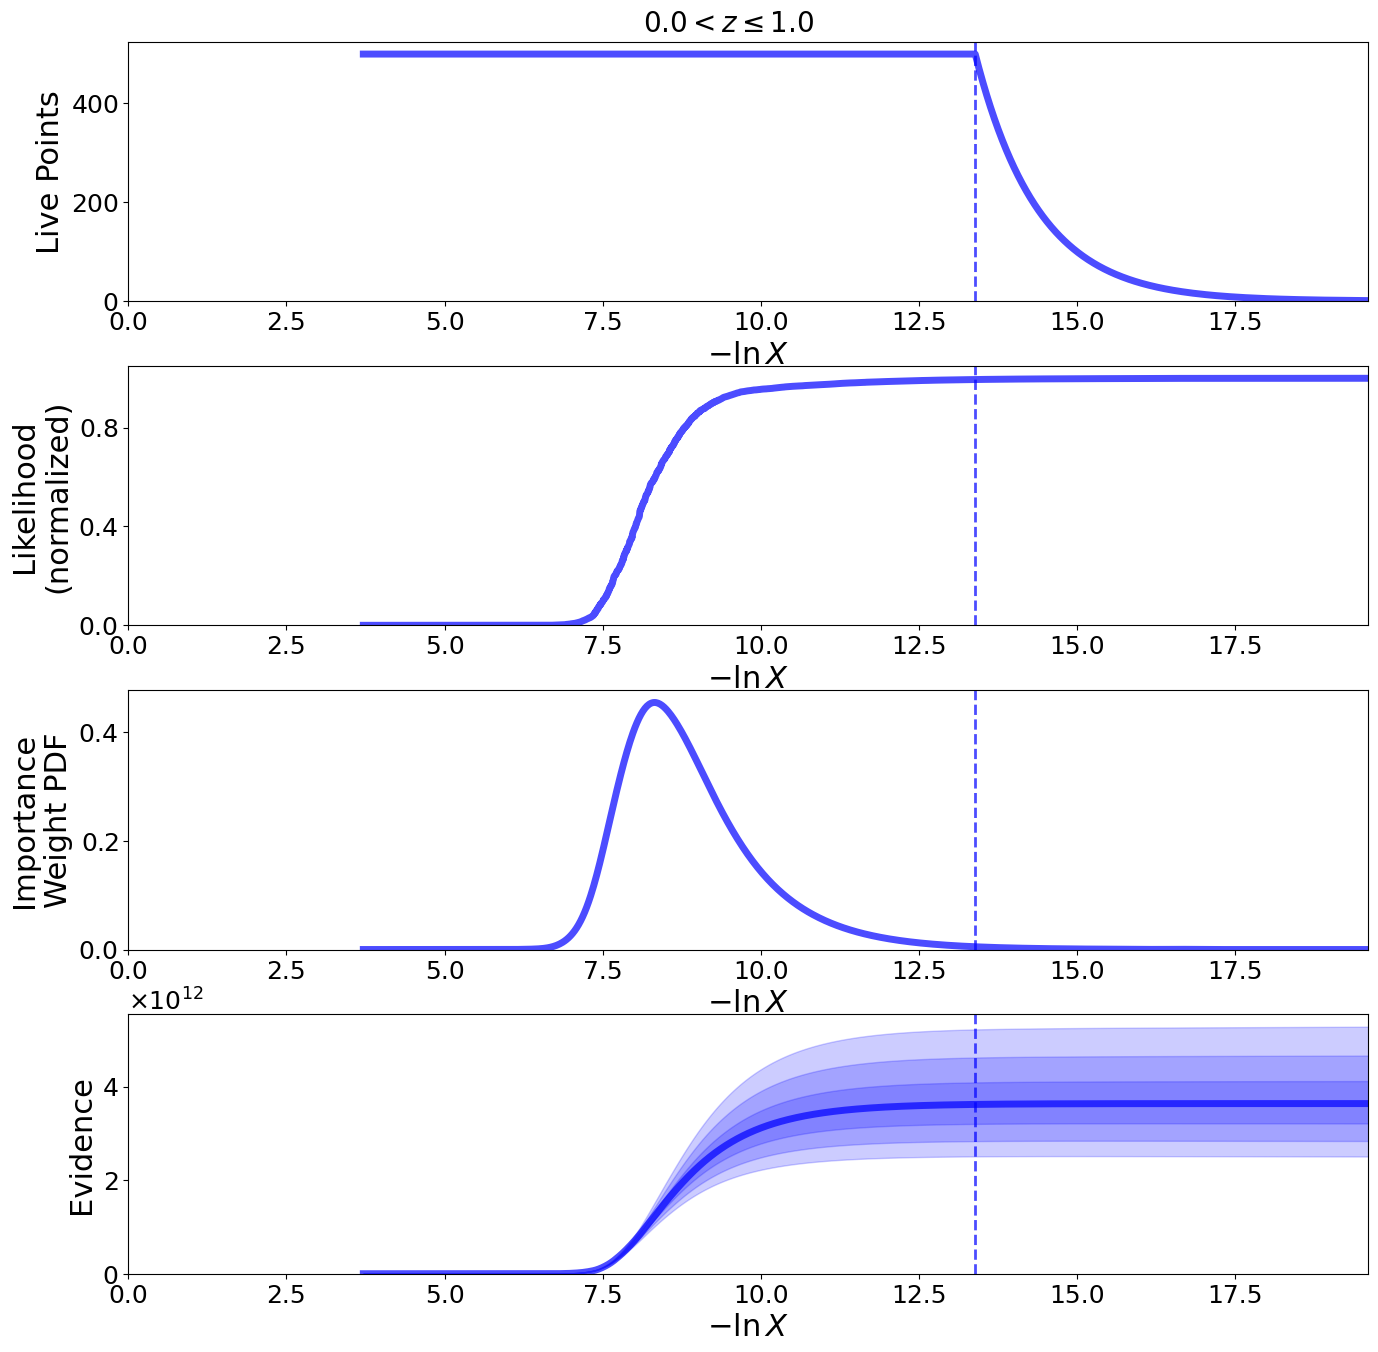

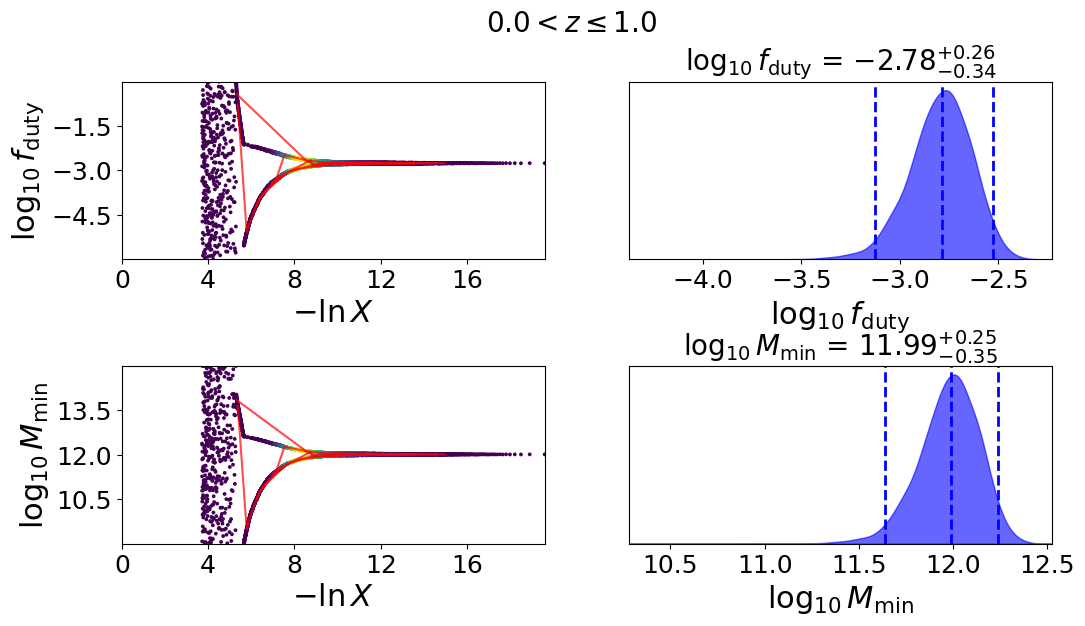

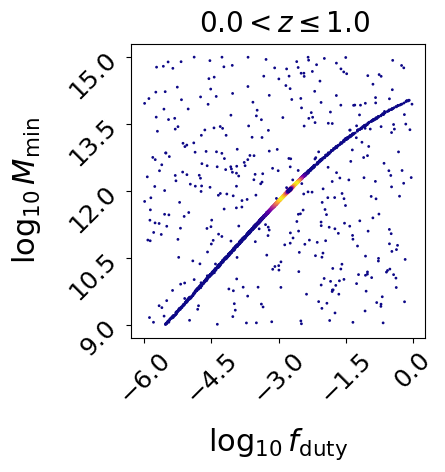

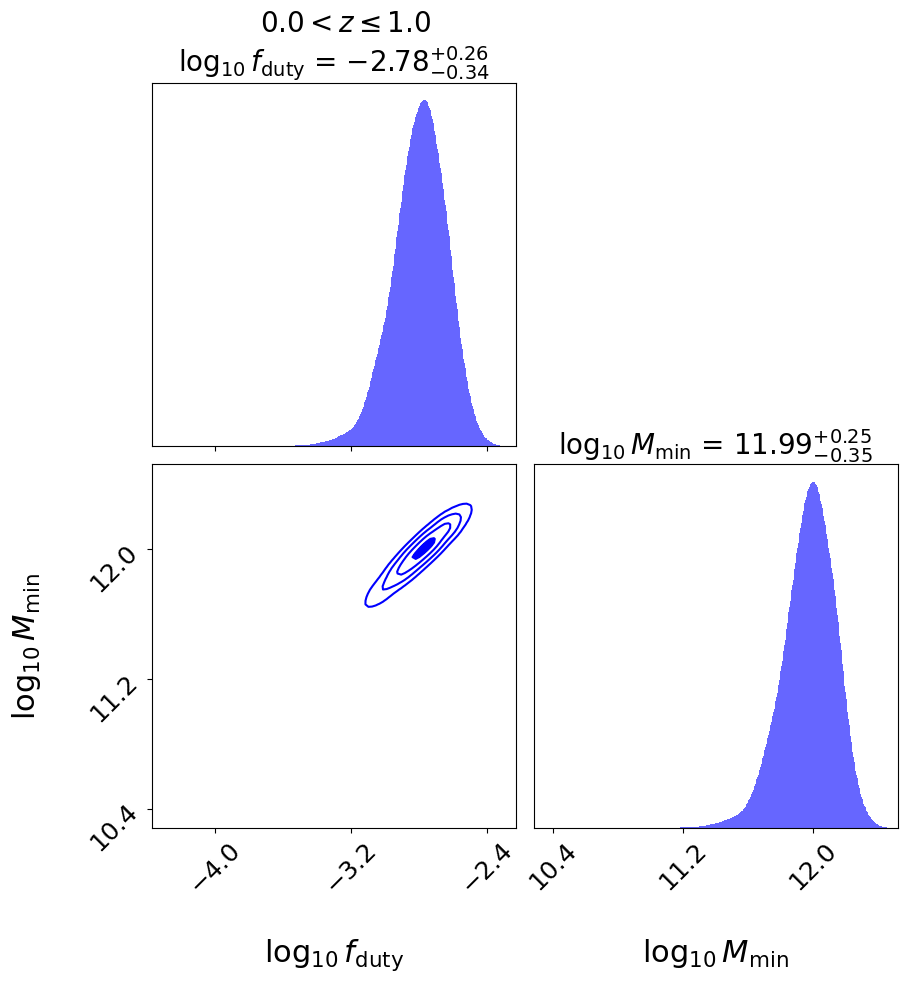

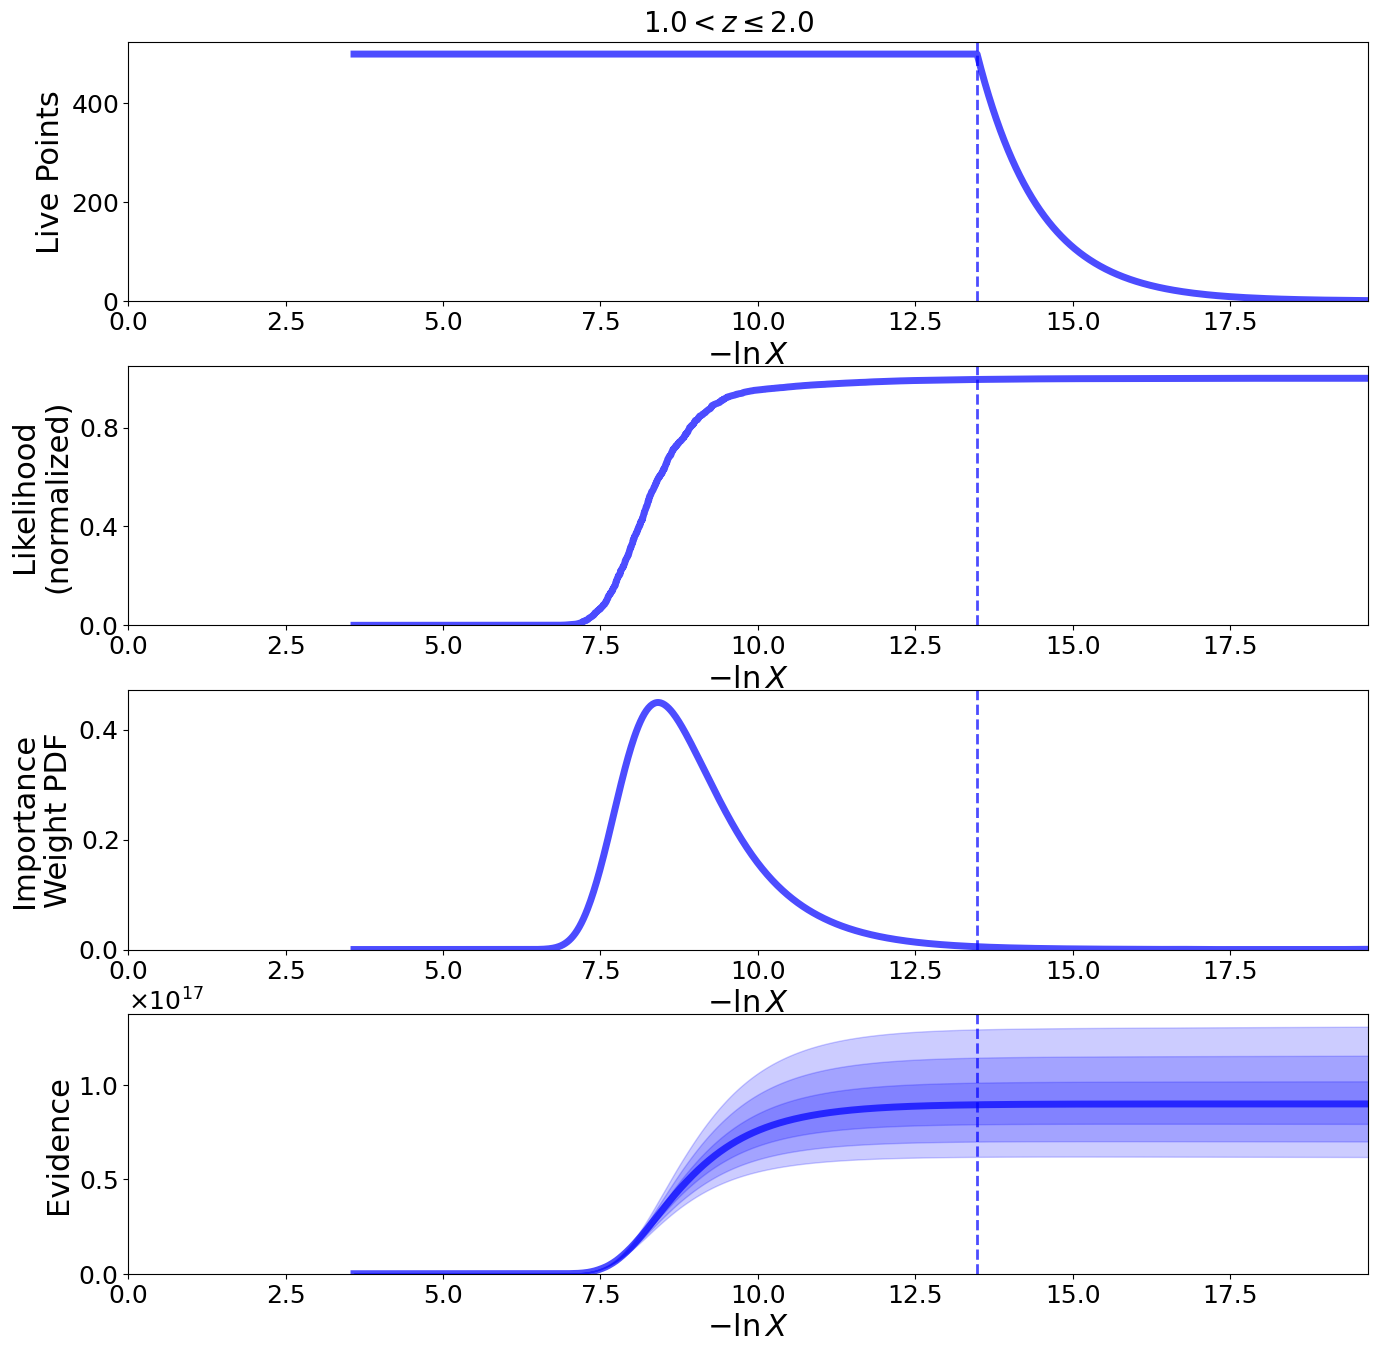

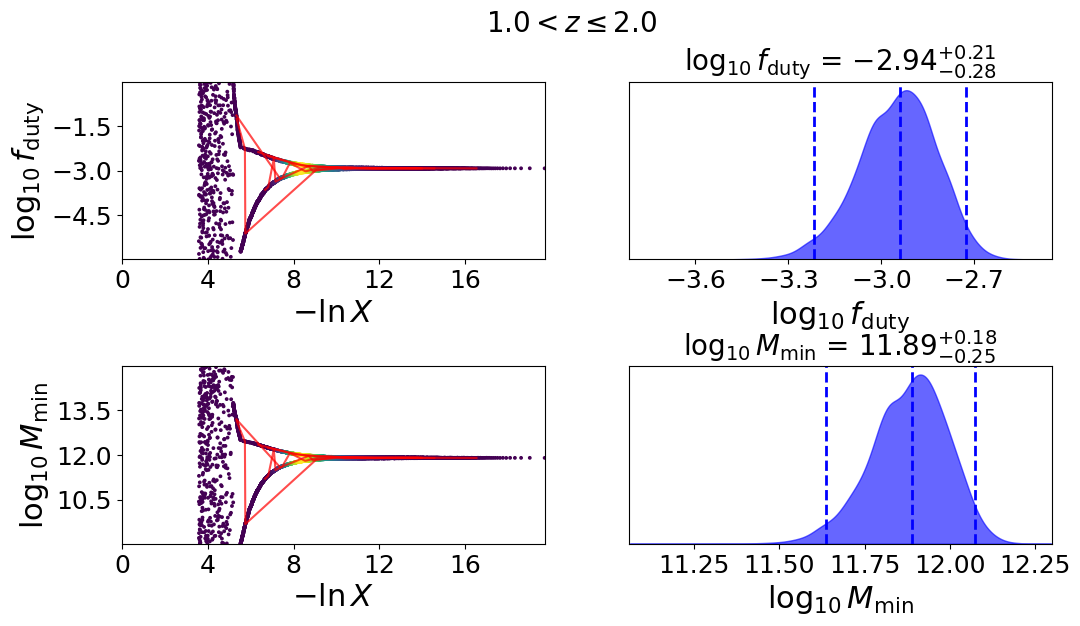

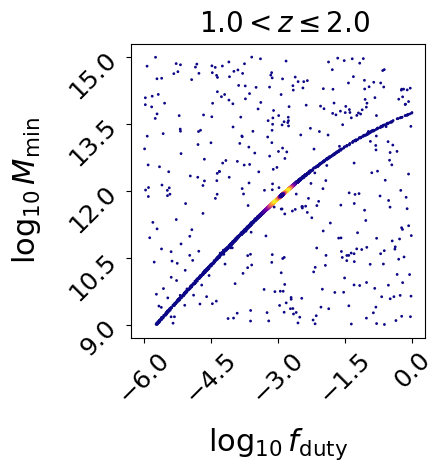

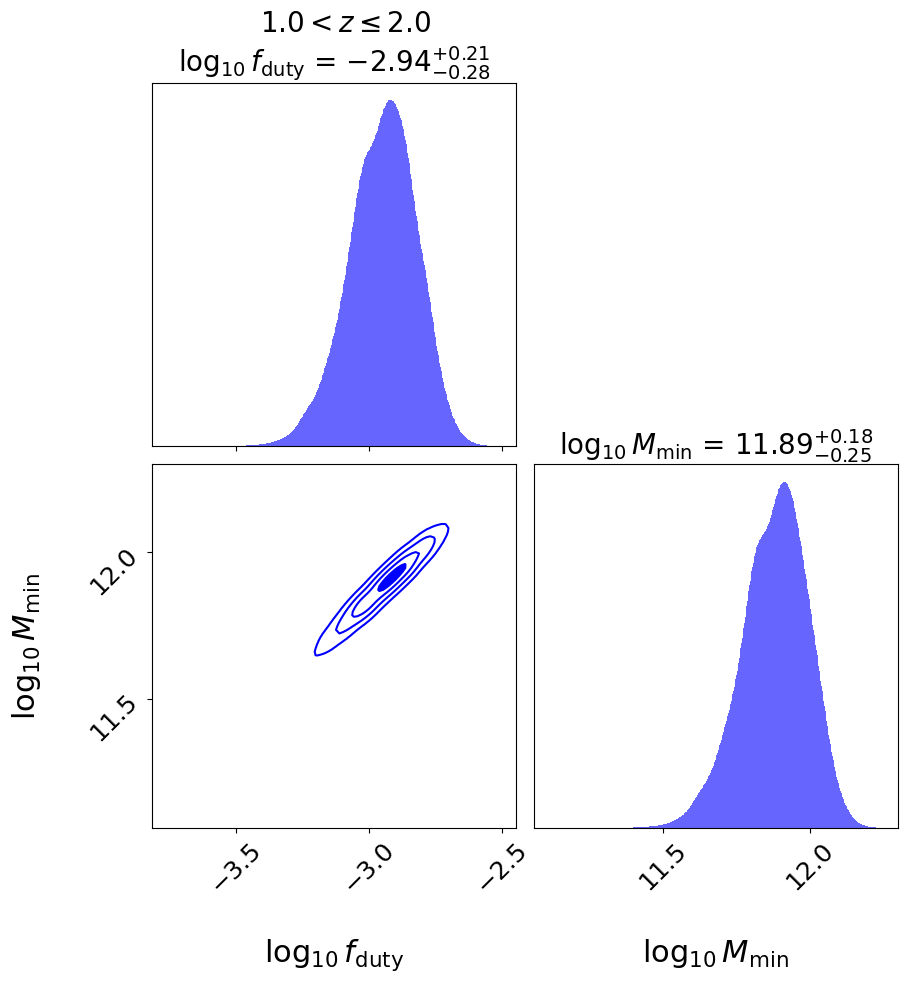

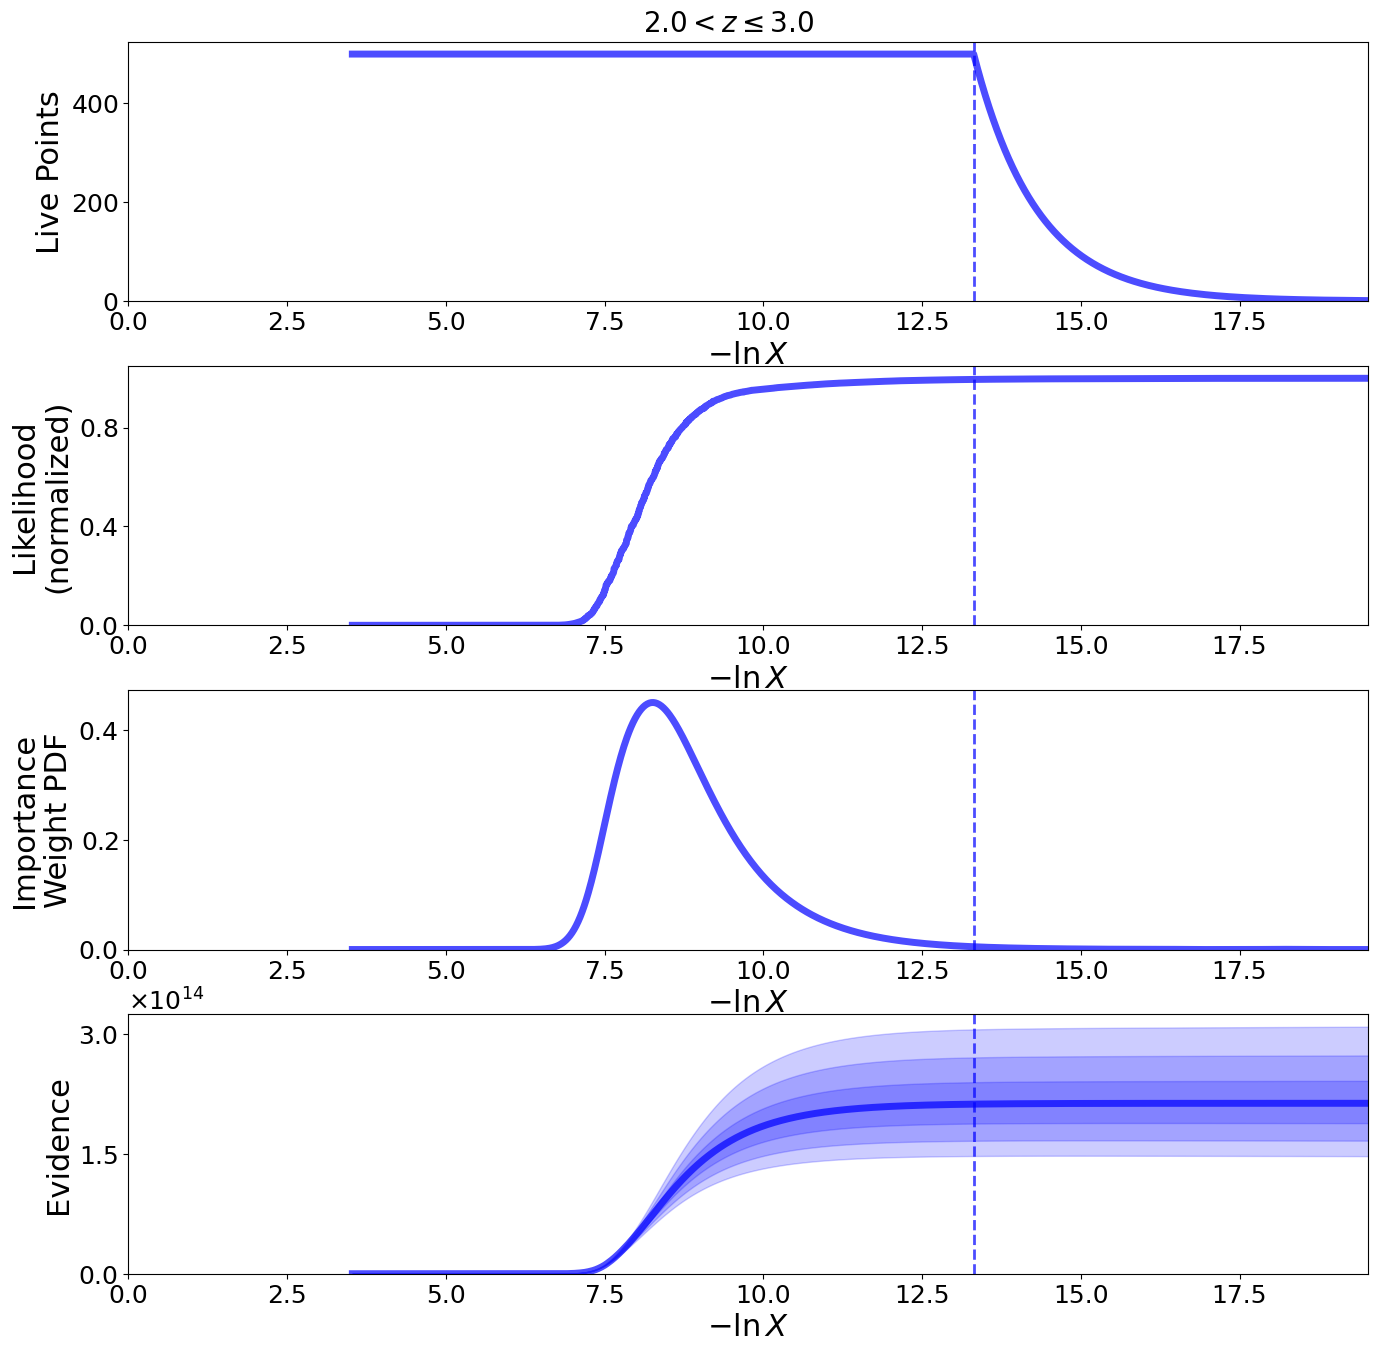

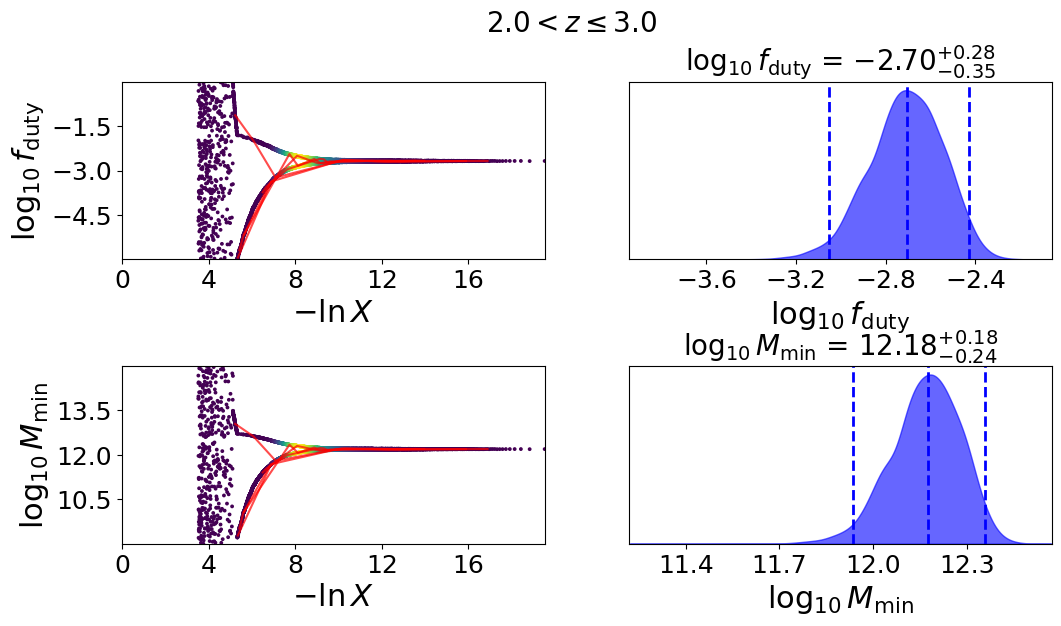

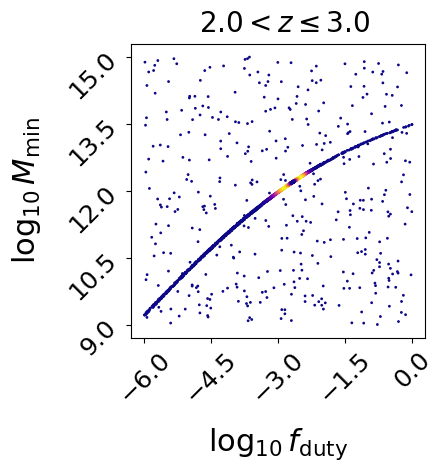

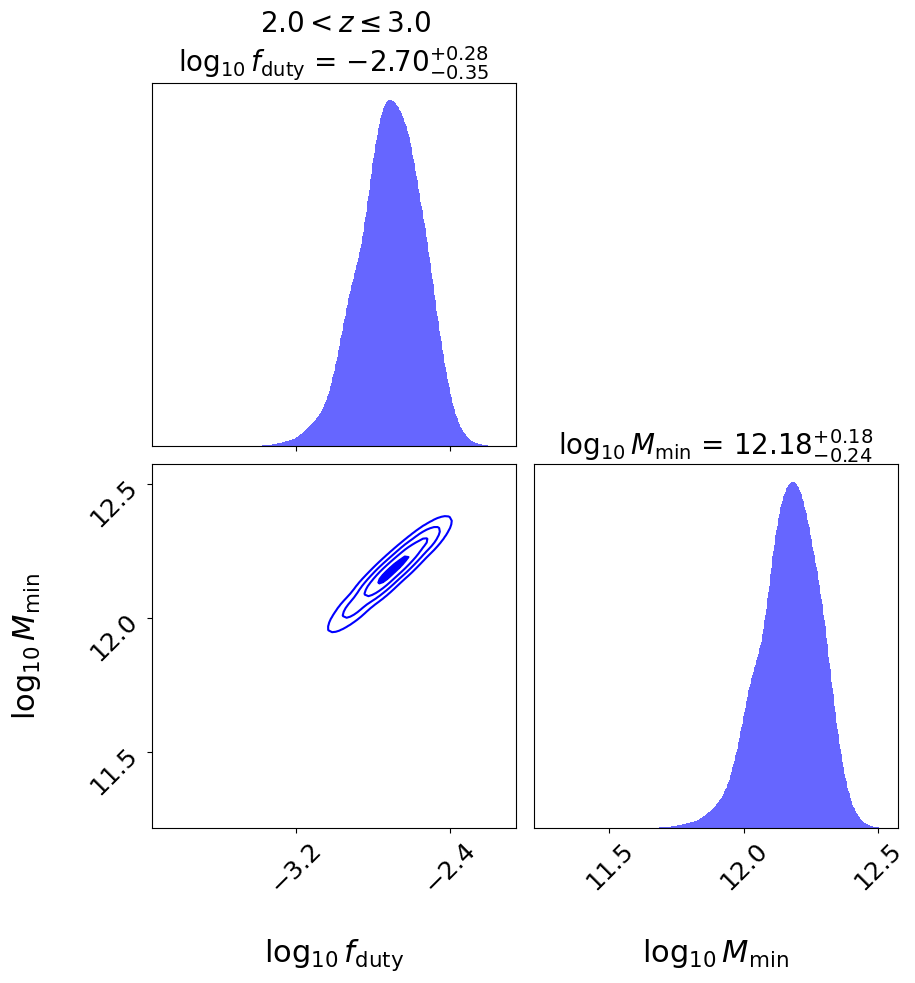

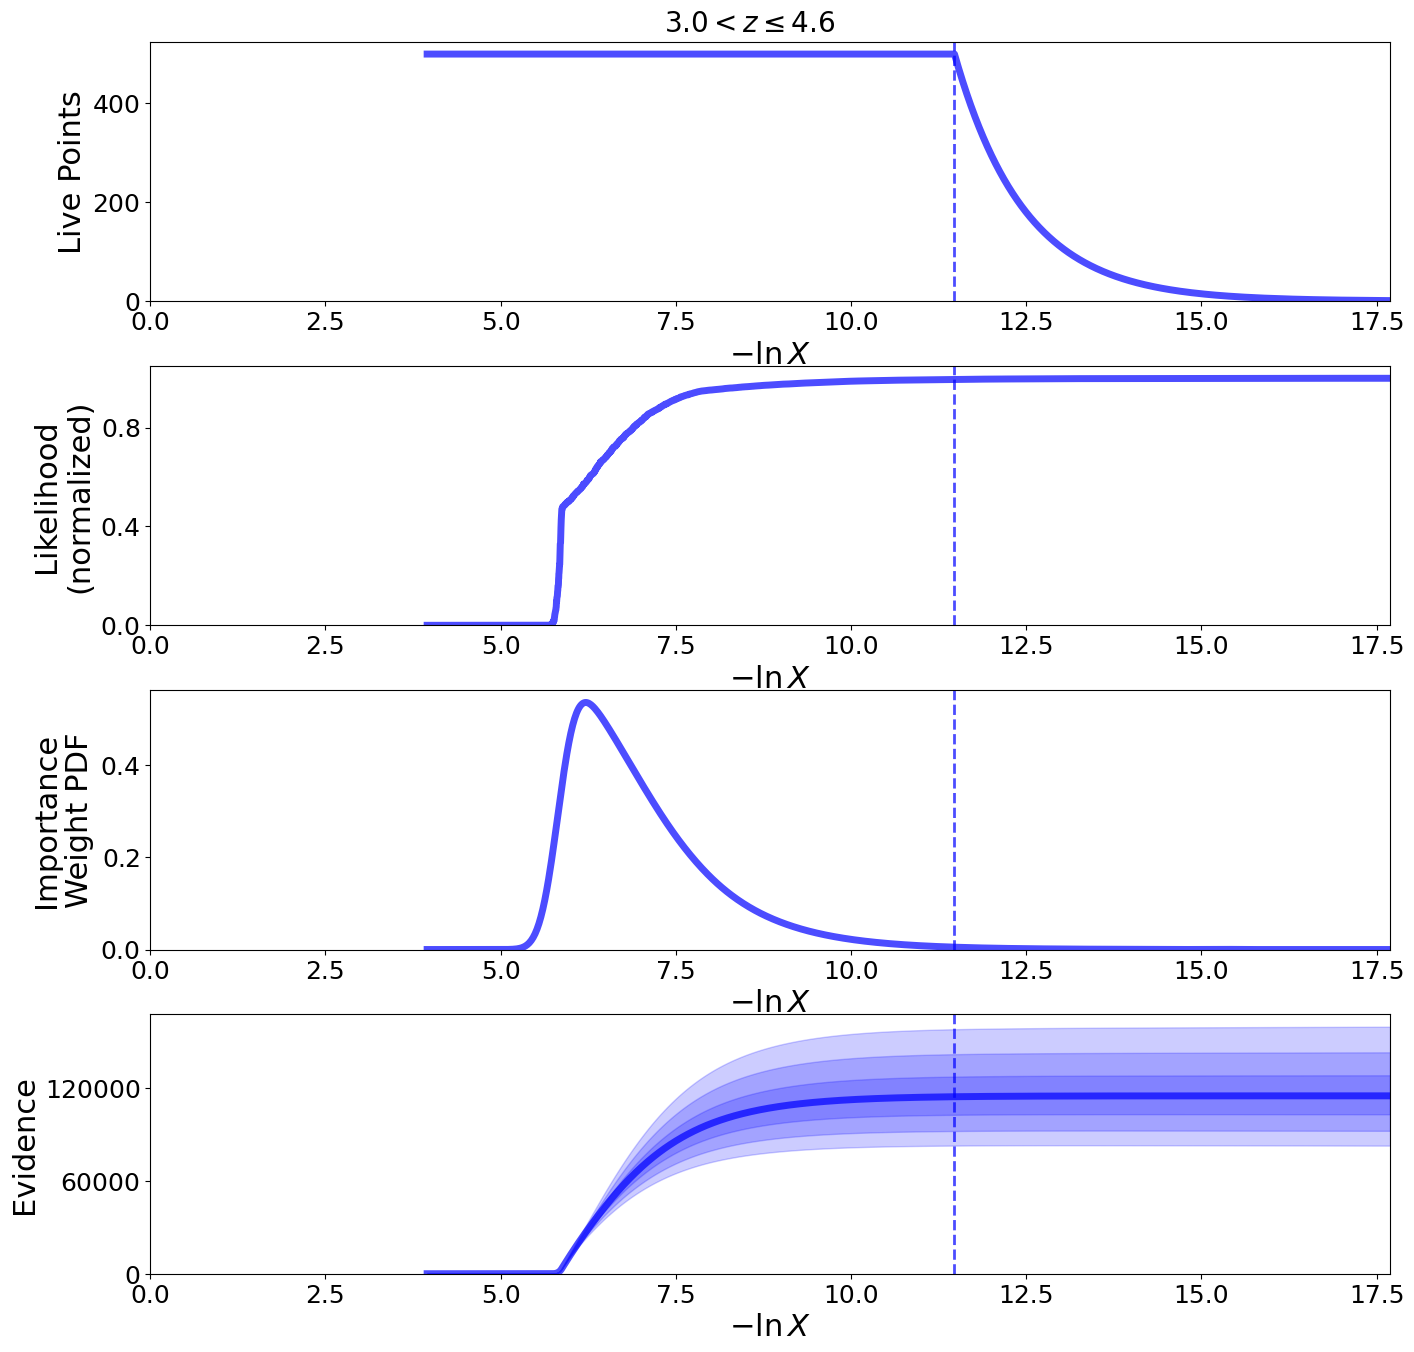

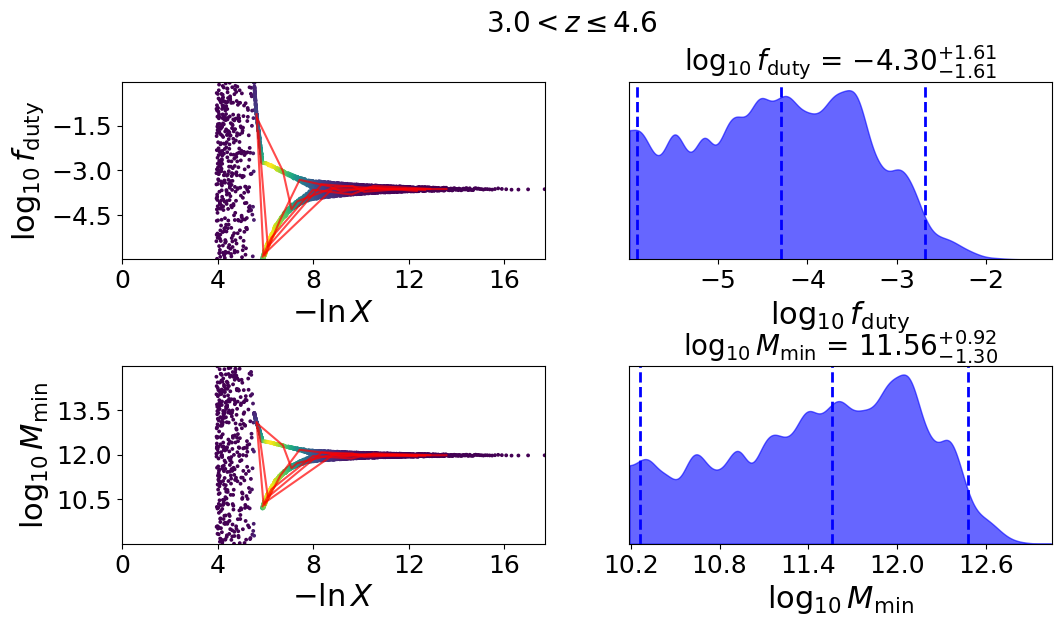

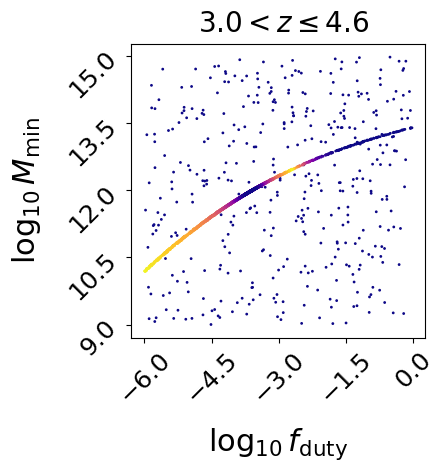

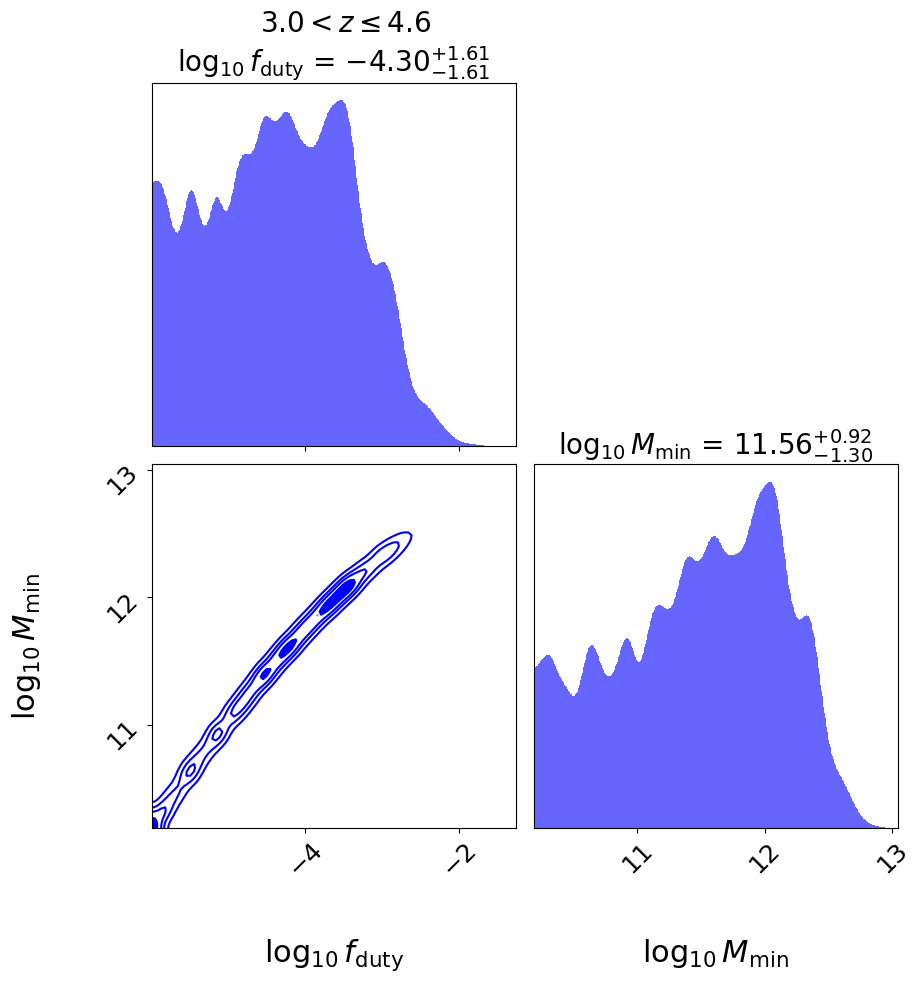

In [61]:
f_duty, M_min = [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ix_grid = np.ix_(rpmask, rpmask)

    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        solve = lambda rhs: linalg.lu_solve(C_factor, rhs)

    # initialize our nested sampler
    # sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], log_det_C, cf_chi2[j][rpmask], n_q[j], nbins])

    # run the sampler with checkpointing
    sampler.run_nested(dlogz = 0.005)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)    
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                 kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)
    
    # initialize figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)
    
    samples, weights = results.samples, results.importance_weights()

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for k, (lo, mid, hi) in enumerate(quantiles):
        print(f"{labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[k]].append((lo, hi))
    print()
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples[ind][:,0])
    M_min_samples.append(equal_weight_samples[ind][:,1])
    
    f_duty.append(quantiles[0][1])
    M_min.append(quantiles[1][1]) 

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [62]:
def f0_GLS_solve(x, a, cf_matter, C, cf, cosmo = cosmo_planck18, M_max = M_max, hartlap = hartlap):  #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
        
    return delta.T @ (hartlap*np.linalg.solve(C, delta))

### Add a number density constraint

In [63]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [64]:
for j in z_array:
    
    print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
    x = 10**f_duty[j], M_min[j]
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    chi2 = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j])
    df = nbins-len(x)

    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

0.0<z<=1.0
           chi^2: 29.65
   reduced chi^2: 3.71
         delta n: 4.76e-02
condition number: 23.69
             PTE: 0.00

1.0<z<=2.0
           chi^2: 12.50
   reduced chi^2: 1.56
         delta n: 4.96e-02
condition number: 20.96
             PTE: 0.13

2.0<z<=3.0
           chi^2: 9.15
   reduced chi^2: 1.14
         delta n: 4.64e-02
condition number: 12.65
             PTE: 0.33

3.0<z<=4.6
           chi^2: 18.96
   reduced chi^2: 2.37
         delta n: 3.56e-02
condition number: 32.00
             PTE: 0.02



## Plot results

In [65]:
zbin = 1/np.array(a_zbin)-1

In [66]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [67]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/1338342386.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


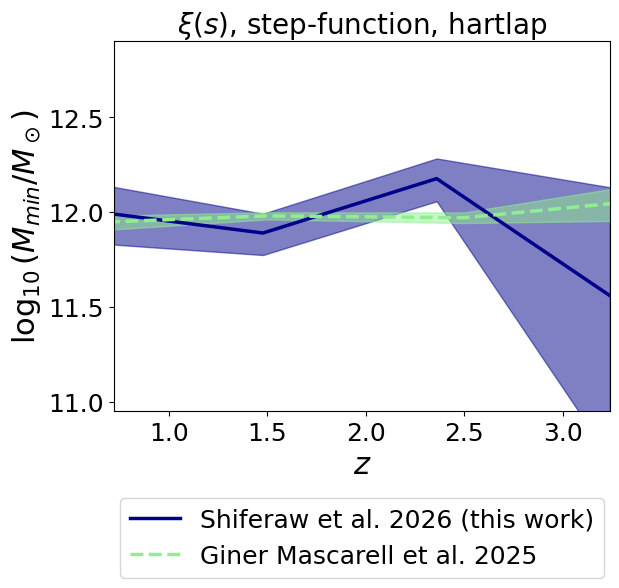

In [68]:
M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = 'darkblue')
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = 'lightgreen')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(10.95,12.9)
plt.title(r'$\xi(s)$, step-function, hartlap')
plt.show()

In [69]:
np.save('../results/M_min_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_hartlap.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo), M_min)

In [70]:
np.save('../results/log10(M_min)_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_hartlap.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo), np.array(err['log10(M_min)']))

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/13619682.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


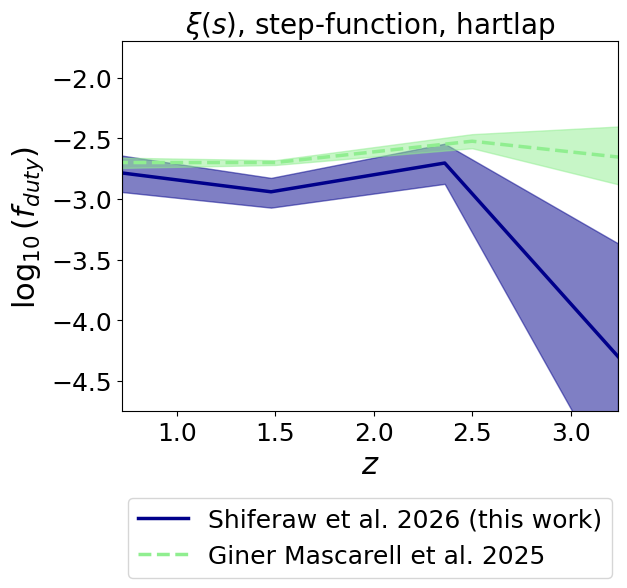

In [89]:
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = 'darkblue')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(-4.75,-1.7)
plt.title(r'$\xi(s)$, step-function, hartlap')
plt.show()

In [72]:
np.save('../results/f_duty_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_hartlap.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo), f_duty)

In [73]:
np.save('../results/log10(f_duty)_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_hartlap.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo), np.array(err['log10(f_duty)']))

In [74]:
b_eff_cf20 = np.load('../results/b_eff_cf20_planck18.npy')

## Calculate 16th and 84th percentile of derived parameters

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/1969771686.py:62: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


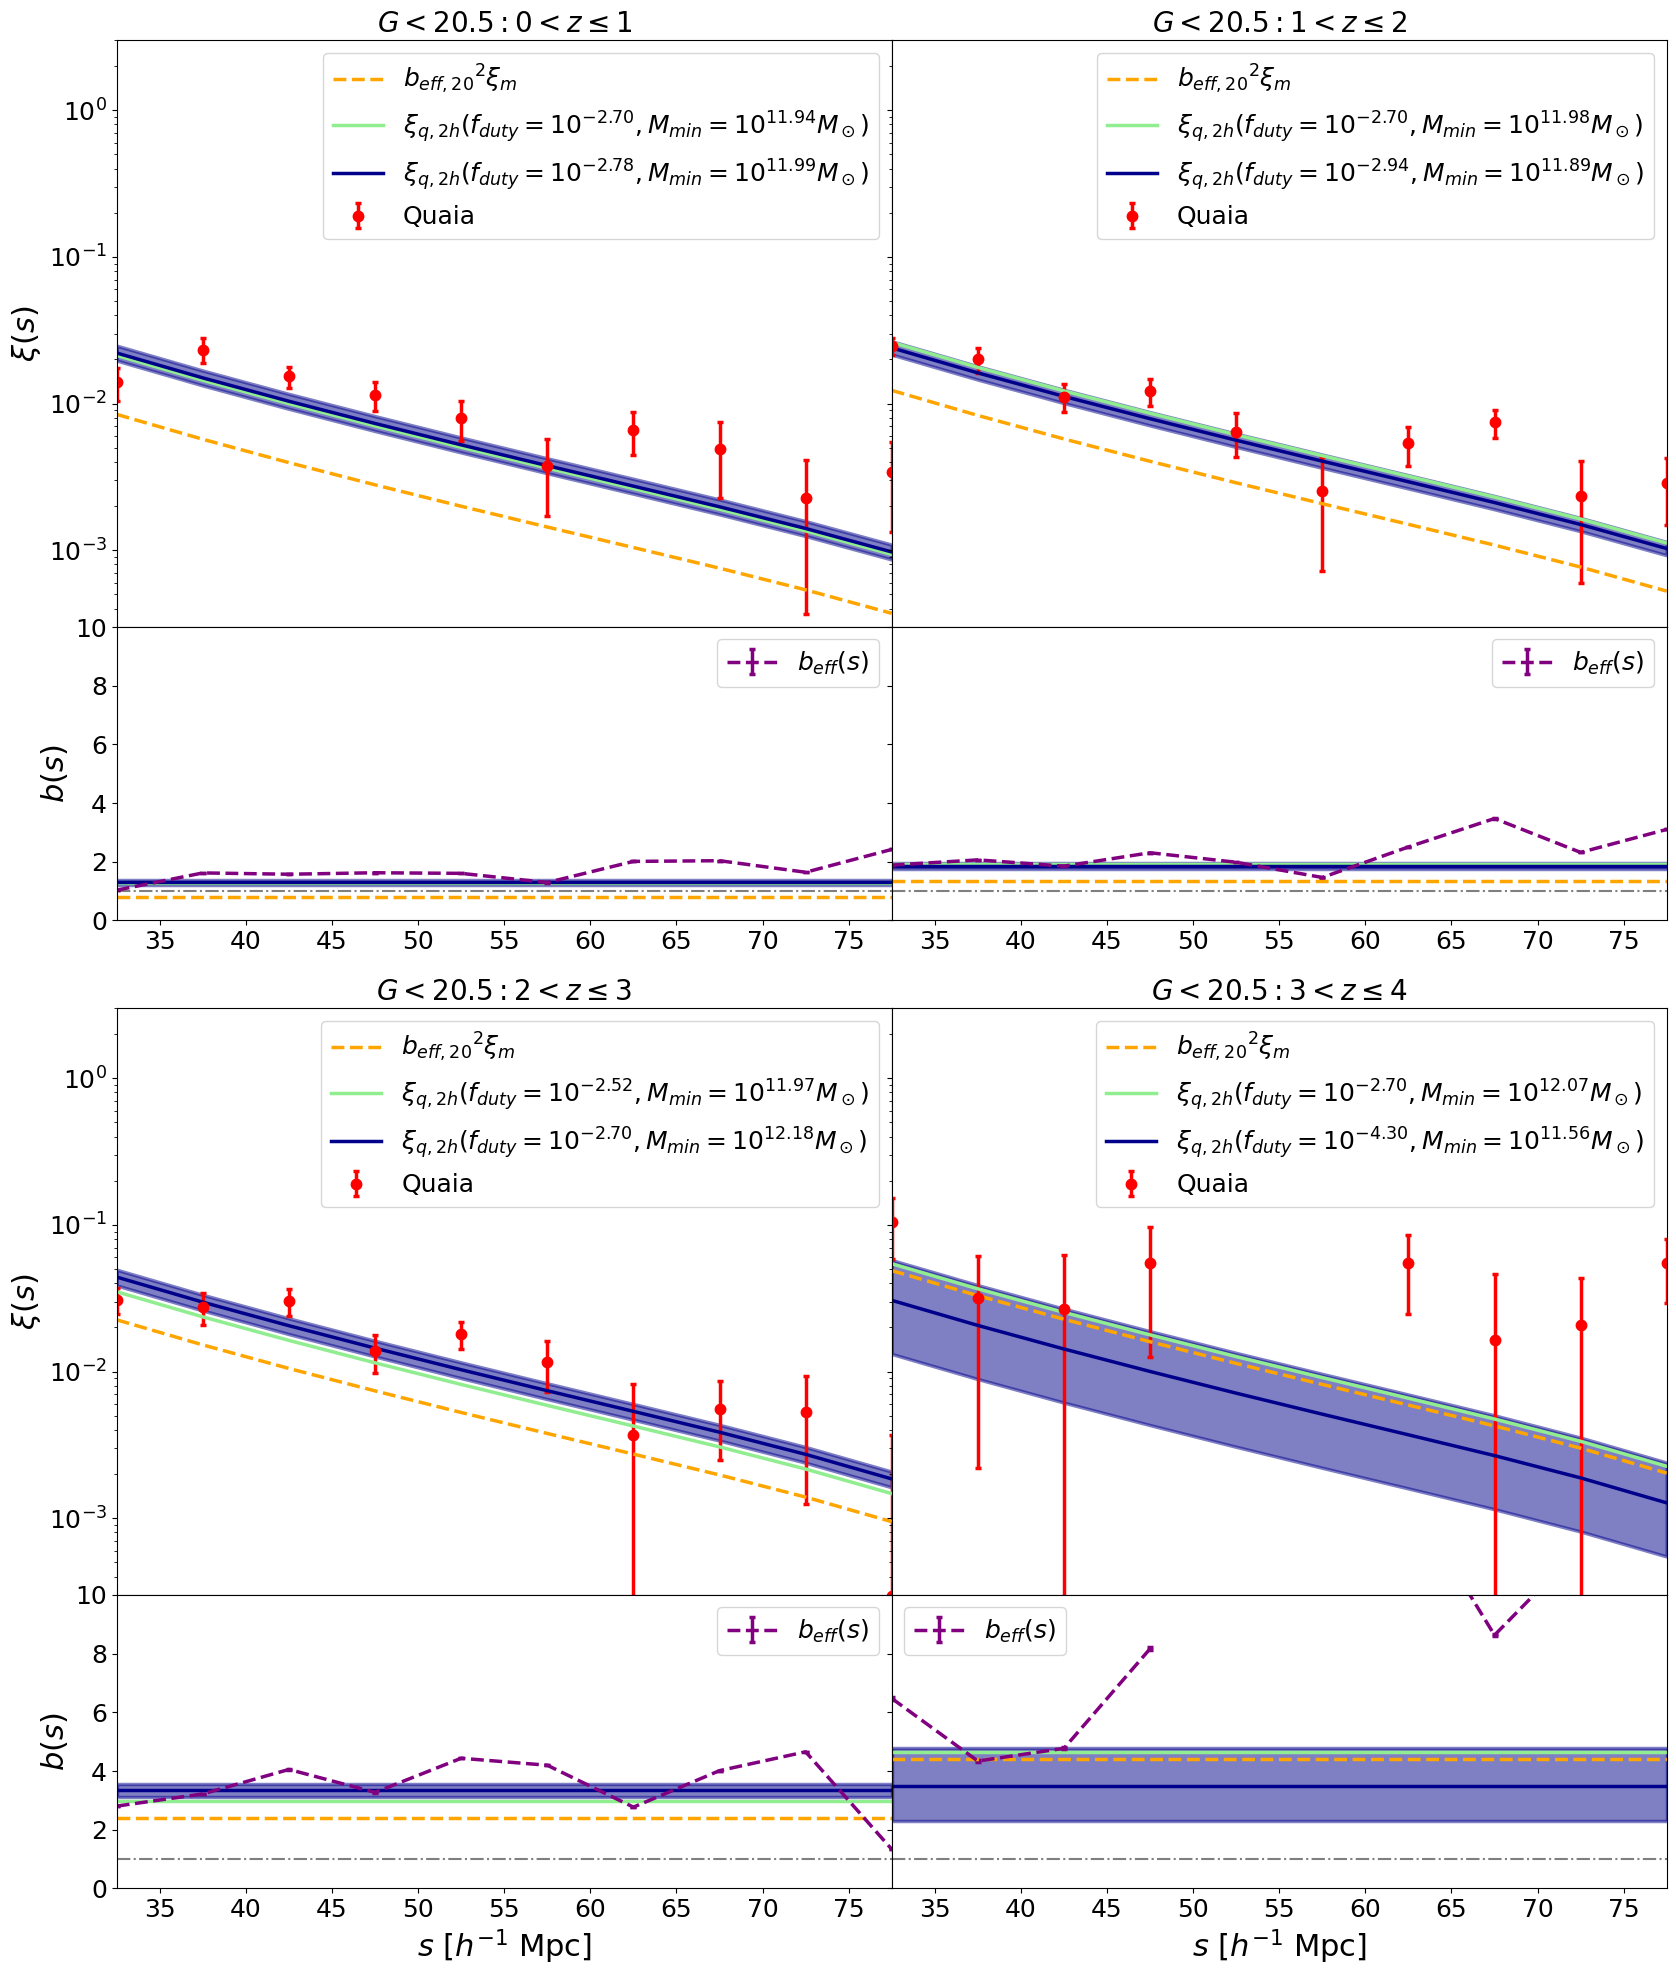

In [75]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
   
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    
    cf_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
        b_q_samples.append(b_q_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/3736729021.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


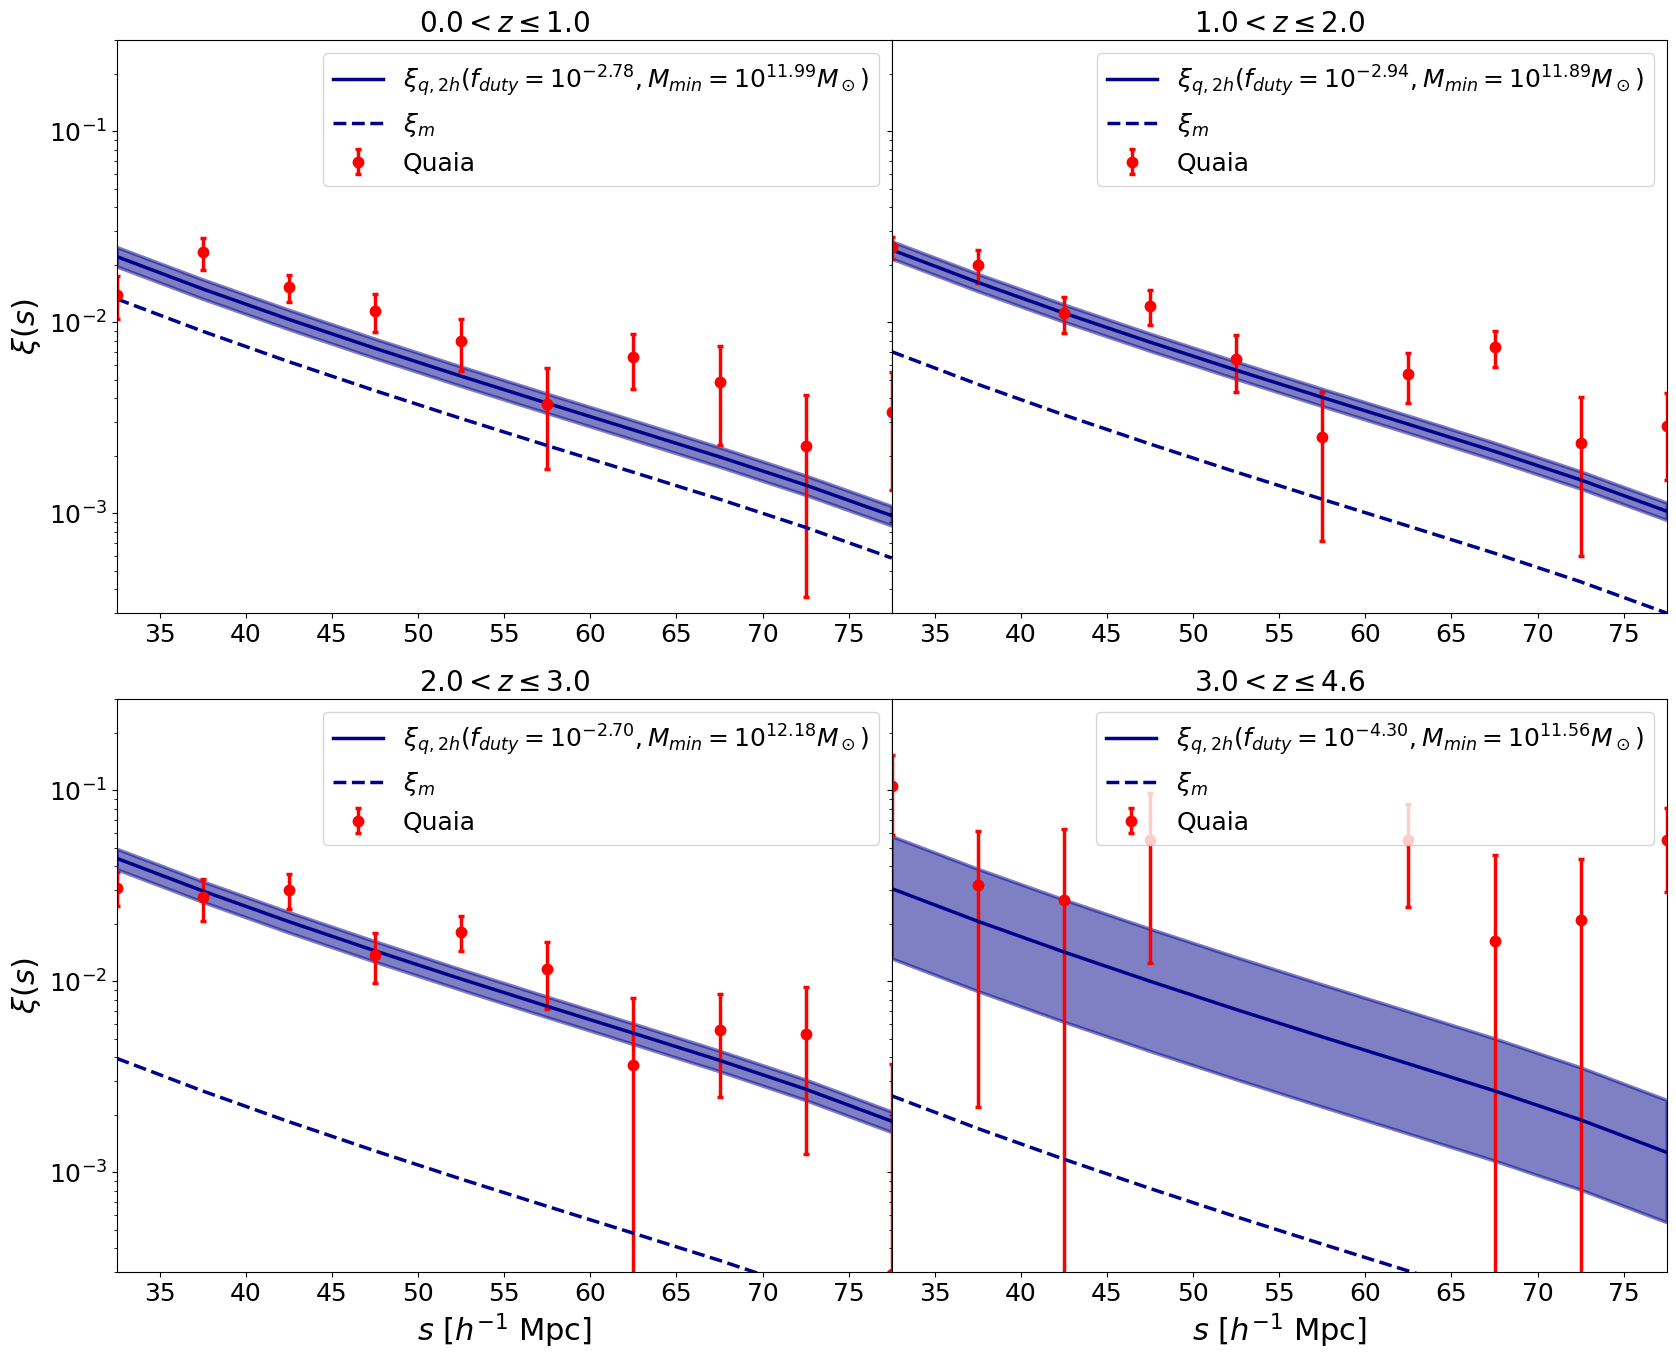

In [76]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins_chi2), cf_matter_chi2[j], linewidth = 2.5,
             label = r'$\xi_{{m}}$', linestyle = '--', 
             color = 'darkblue')

    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')   

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

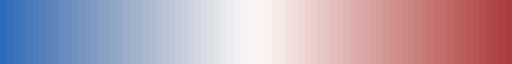

In [77]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_192581/3361964989.py:42: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_192581/3361964989.py:61: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


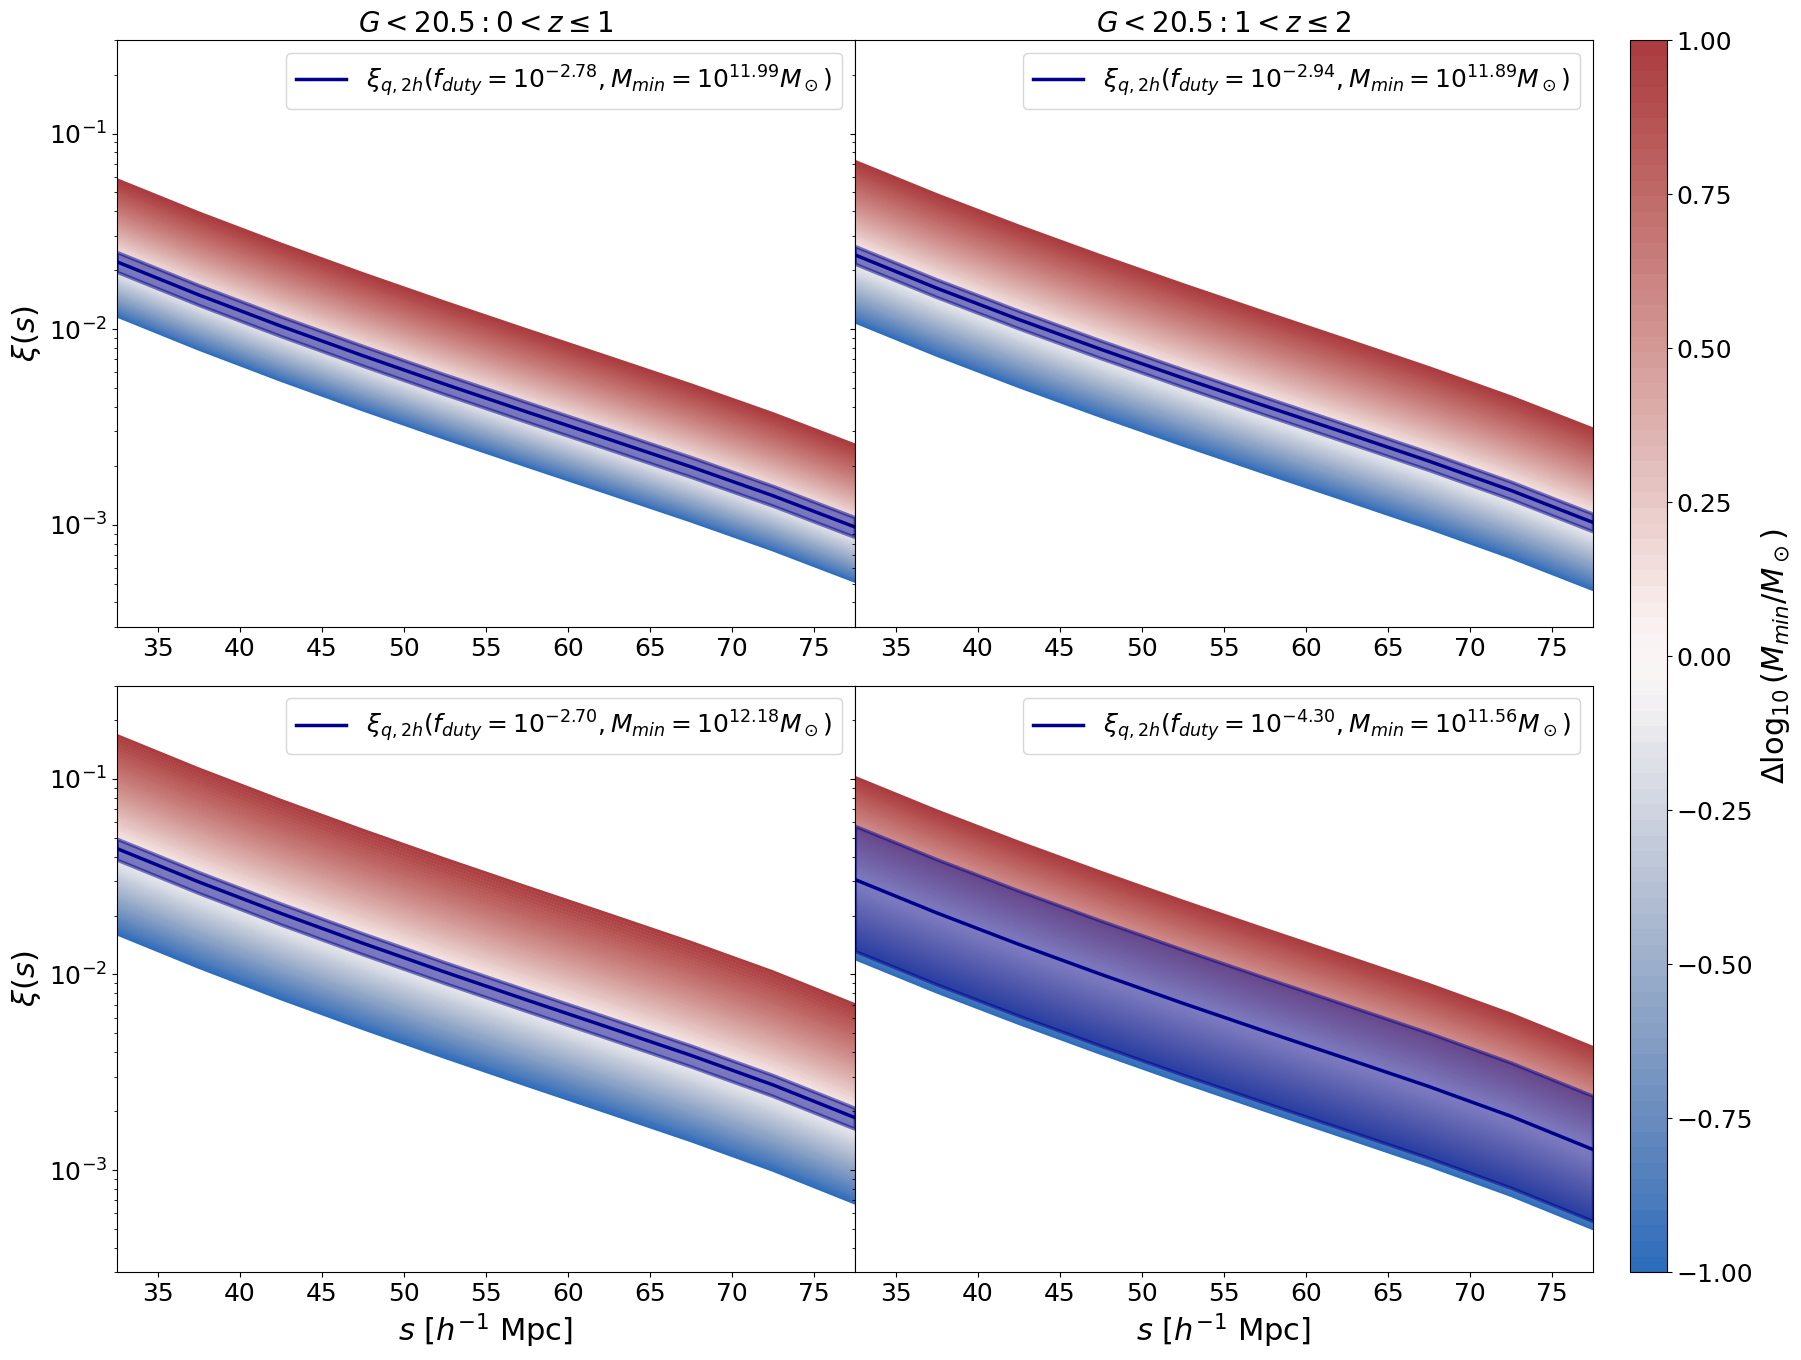

In [78]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 4, hspace = 0.1, wspace = 0, width_ratios = [1,1,0.05,0.05])

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    for k in range(len(bins)):
        cf_2h_sample, _ = cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)
        ax1.plot(quaia.recenter(rbins_chi2), cf_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    
    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [79]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
b_q_lo, b_q_hi = np.array(b_q_percentile).T

<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_192581/2055880083.py:51: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


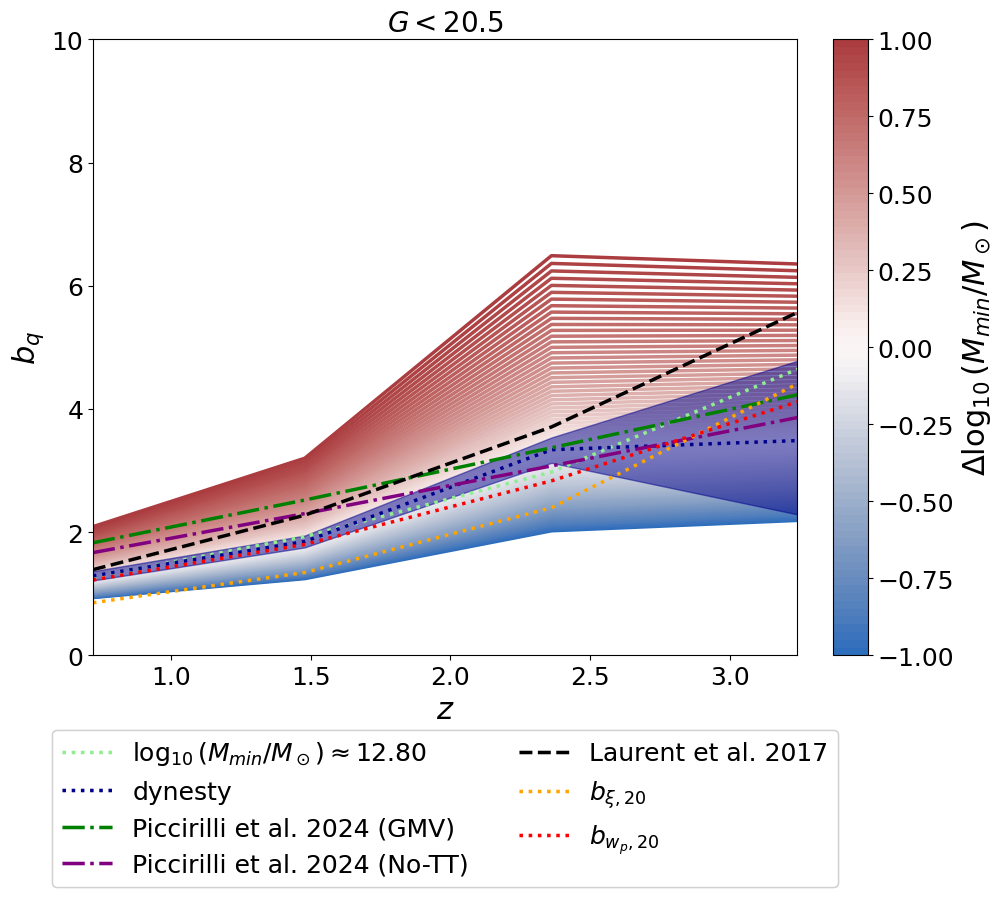

In [80]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_chi2[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [81]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
M_h_lo, M_h_hi = np.array(M_h_percentile).T

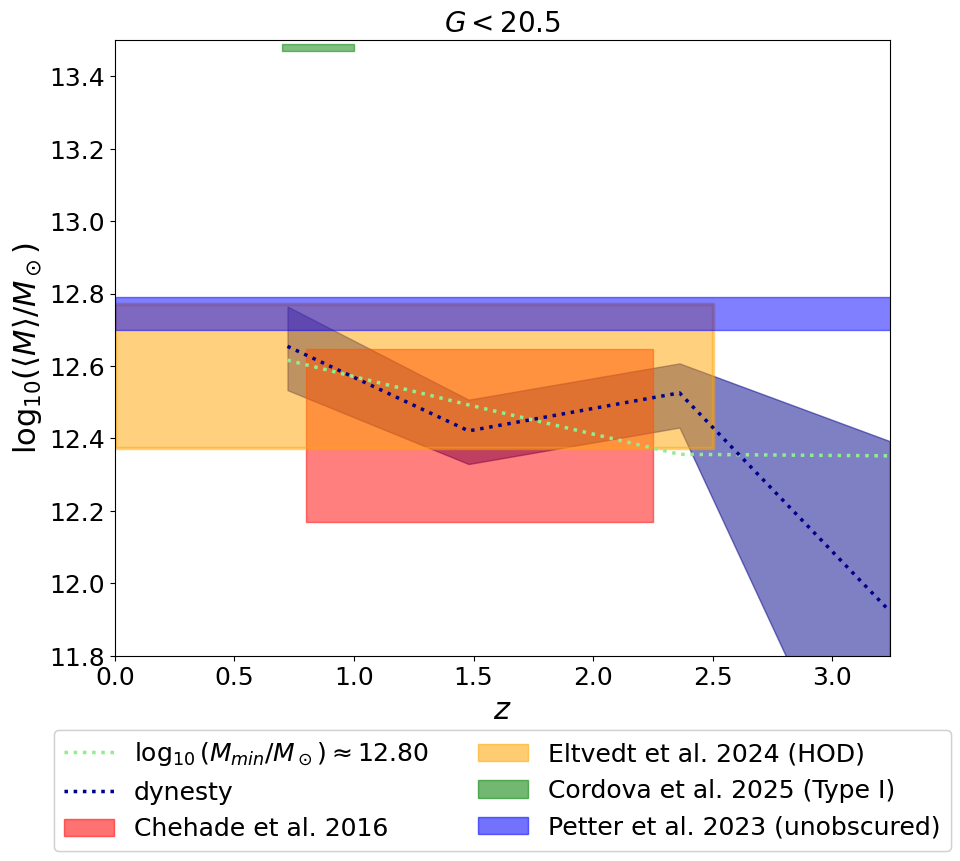

In [82]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_192581/1482196861.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


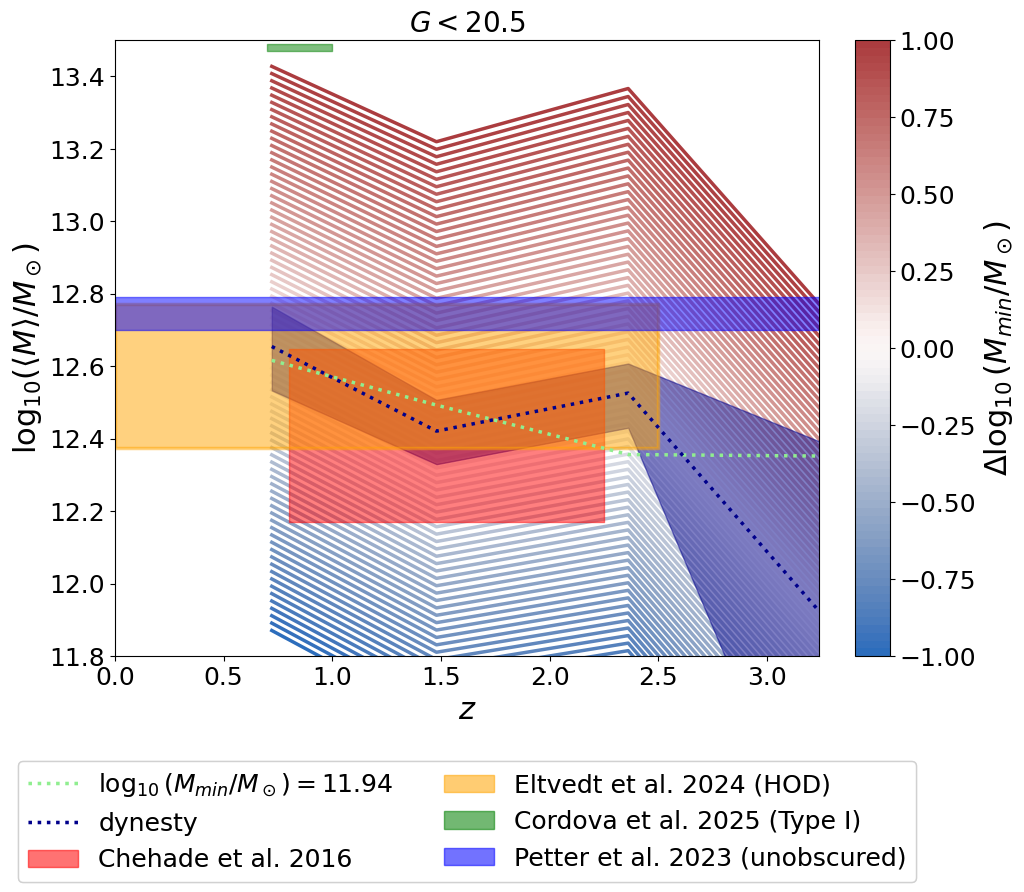

In [83]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(z_array))]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [84]:
fduty_array = np.logspace(-5,0, 51) #-4

In [85]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [86]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_192581/2572909852.py:43: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_192581/2572909852.py:76: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


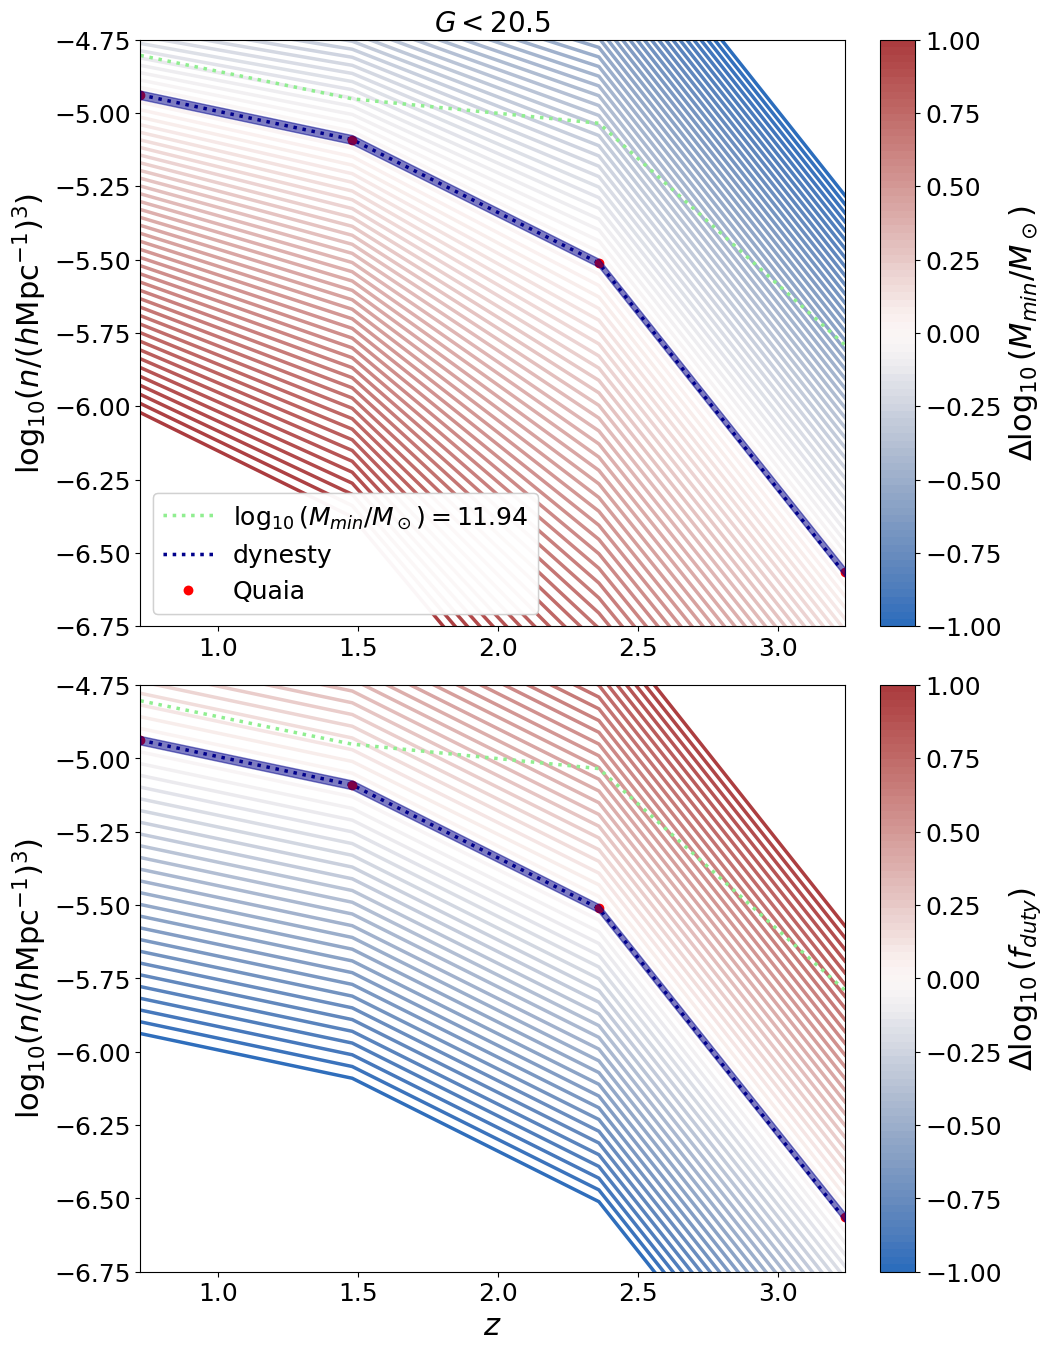

In [87]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -6.75, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])
    
n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    n_q_theory_fit.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')

ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()

# Debug covariance
## Plot the amplitude of the diagonal of the covariance

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_192581/2435090097.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_192581/2435090097.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


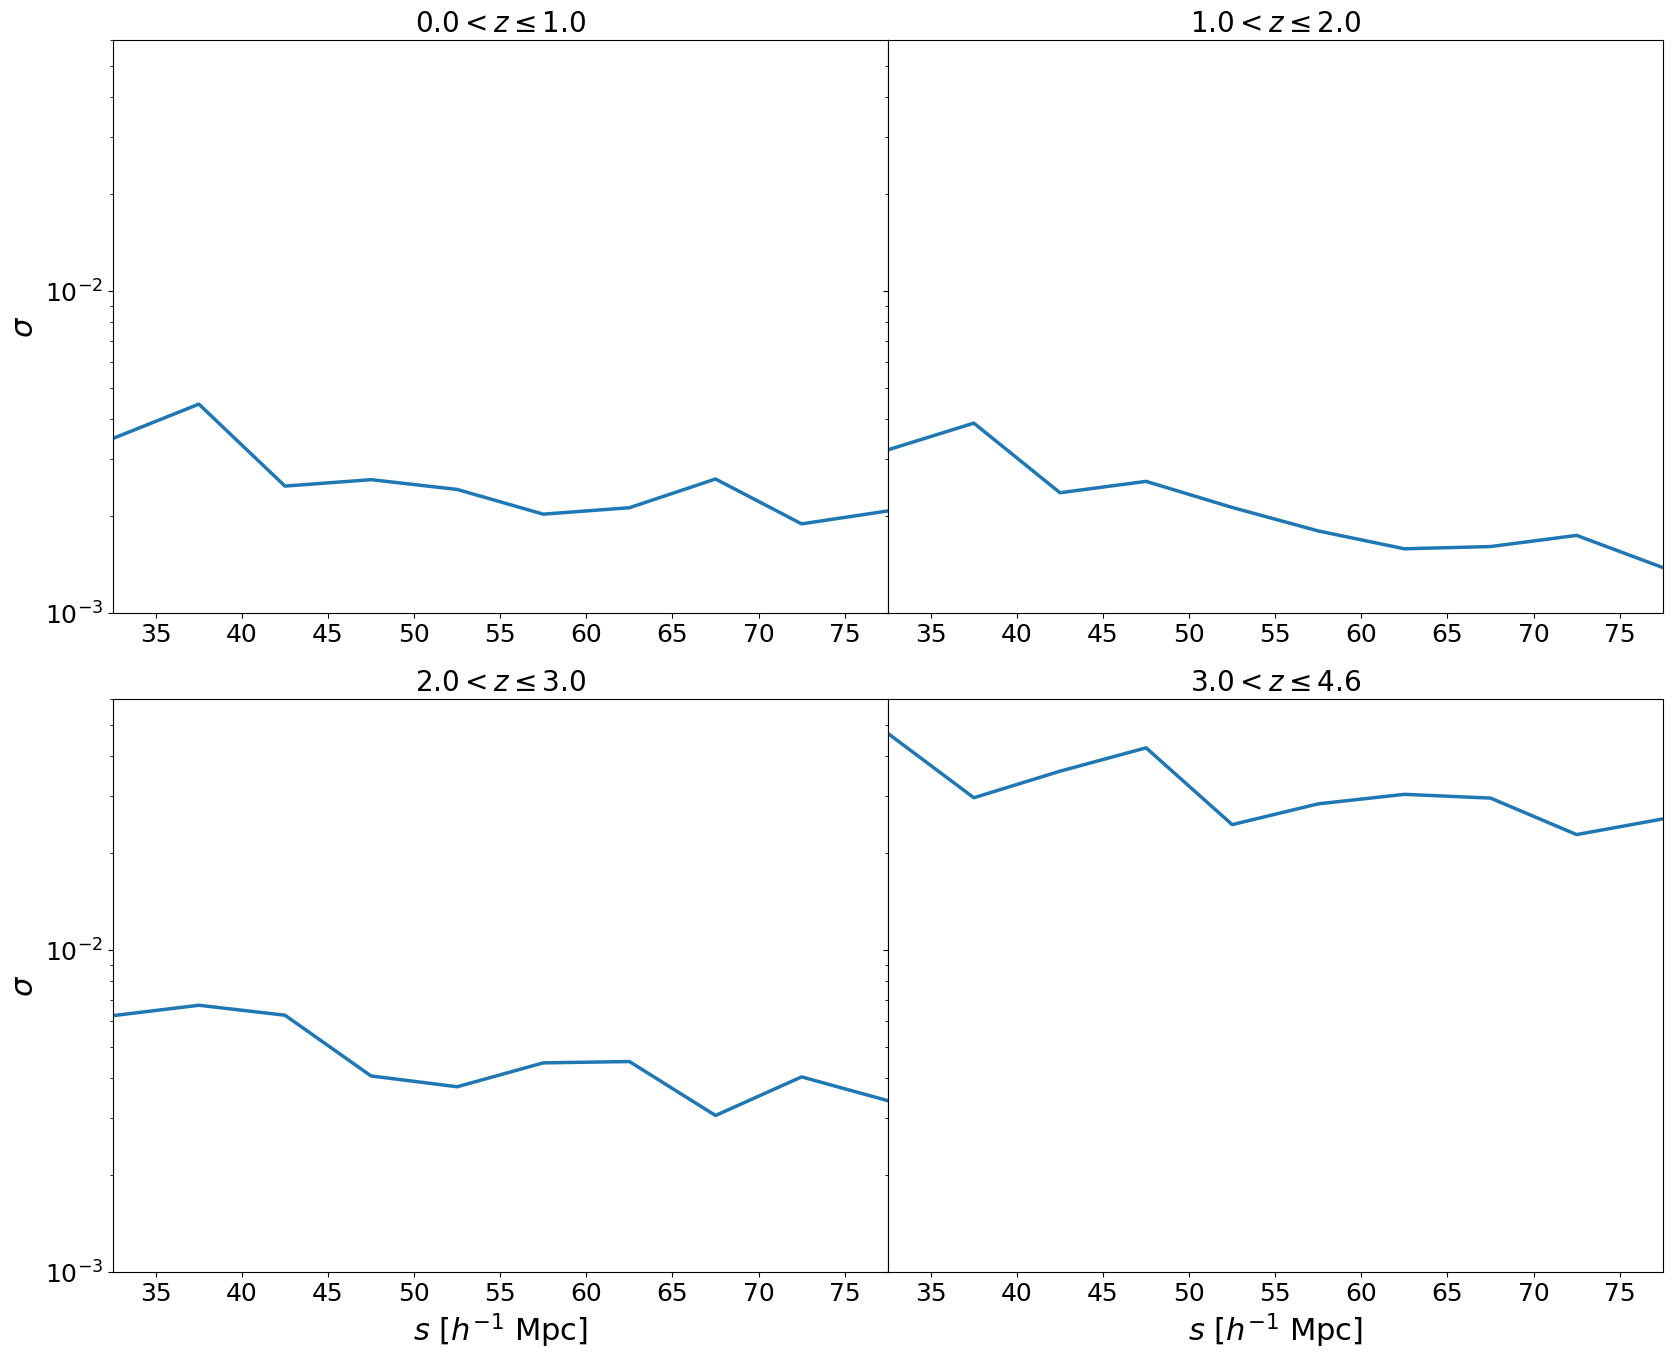

In [88]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)

for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good

    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, label = 'no correction')
    # ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(hartlap*C)), linewidth = 2.5, label = 'with Hartlap correction')
    
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticklabels([])

    ax1.set_ylim(1e-3, 6e-2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

# ax1.legend()
plt.show()